# HCM PRS Study — Cohort & Data Setup
This notebook builds the complete analytical dataset for the HCM polygenic risk score study. It contains **no results or statistical analyses** — only data preparation and cohort assembly.

## What This Notebook Does
1. **HCM Cohort Definition**  
   Identify all patients with hypertrophic cardiomyopathy diagnosis using validated phenotyping algorithms

2. **Polygenic Risk Score Calculation**  
   Compute PRS (PGS000739) for all genotyped samples with percentile and quartile assignments

3. **Pathogenic Variant Carrier Identification**  
   Flag carriers of pathogenic variants across the sarcomere gene panel

4. **Clinical Outcome Event Extraction**  
   Build event tables for MACE outcomes (heart failure, arrhythmias, cardiac arrest / sudden death, stroke, etc) and interventions (ICD, ablation, transplant, septal reduction, etc) from OMOP clinical data

5. **Master Cohort Table Assembly**  
   Integrate genetics + demographics + outcomes into a single table with four cohort groups:
   - **HCM Carriers**: HCM diagnosis + pathogenic variant
   - **HCM Non-Carriers**: HCM diagnosis without pathogenic variant  
   - **GenPop Carriers**: Pathogenic variant without HCM diagnosis
   - **GenPop Non-Carriers**: Neither HCM nor pathogenic variant

## Output
- `hcm_master_cohort` table in BigQuery (scratch dataset), including `is_hcm_case` (strict cohort-eligibility diagnosis) and `has_hcm` (minimal-criteria diagnosis)
- Supporting tables: `event_mapping`, `condition_events`, `procedure_events`, `death_events`, `cardiac_arrest_death_events`, `last_visit_date`
- Local files: PRS scores, carrier status

**Run this notebook top-to-bottom once per data refresh** before running analysis notebooks.

---
**Author**: Melanie Fernandez  
**Institution**: NashBio  
**Last Updated**: 08/30/2026

## 1. HCM Cohort Definition
Identifies primary (sarcomeric-candidate) HCM cases: patients with a
qualifying number of HCM diagnosis codes, **no** competing diagnosis that
explains hypertrophy through a known secondary cause, and echocardiographic
confirmation near the diagnosis date.

**Pipeline:**
1. Define primary HCM ICD codes and exclusion ICD codes (secondary causes of LV hypertrophy)
2. Map both code lists to OMOP standard concept_ids
3. Search for each across `condition_occurrence`, `procedure_occurrence`,
   `measurement`, and `observation`
4. Apply the diagnosis-count case rule and drop anyone with an exclusion diagnosis
5. Require an echocardiogram within 1 year before / 2 years after first HCM diagnosis
6. Report prevalence

### 1a. ICD code lists

In [46]:
HCM_PRIMARY_ICD10 = ["I42.1", "I42.2"]
HCM_PRIMARY_ICD9 = ["425.1", "425.11", "425.18"]

HCM_EXCLUSION_ICD10 = {
    "Ischemic":            ["I25.5"],
    "Alcoholic":           ["I42.6"],
    "Drug_Induced":        ["I42.7"],
    "Metabolic":           ["E75.21", "E74.02"],
    "Peripartum":          ["O90.3"],
    "Takotsubo_Stress":    ["I51.81"],
    "Amyloidosis":         ["E85.4", "E85.81", "E85.82", "E85.89", "E85.9"],
    "Sarcoidosis":         ["D86.85", "D86.89", "D86.9"],
    "Hemochromatosis":     ["E83.110", "E83.111", "E83.118", "E83.119"],
    "HIV_CM":              ["B20"],
    "Muscular_Dystrophy":  ["G71.00", "G71.01", "G71.02", "G71.09"],
    "Congenital":          [
        # Specific congenital heart defects
        "Q20.0", "Q20.1", "Q20.2", "Q20.3", "Q20.4", "Q20.5", "Q20.6", "Q20.8", "Q20.9",  # Q20.x
        "Q21.0", "Q21.1", "Q21.2", "Q21.3", "Q21.4", "Q21.8", "Q21.9",  # Q21.x - Septal defects
        "Q22.0", "Q22.1", "Q22.2", "Q22.3", "Q22.4", "Q22.5", "Q22.6", "Q22.8", "Q22.9",  # Q22.x - Pulmonary/tricuspid
        "Q23.0", "Q23.1", "Q23.2", "Q23.3", "Q23.4", "Q23.8", "Q23.9",  # Q23.x - Aortic/mitral
        "Q24.0", "Q24.1", "Q24.2", "Q24.3", "Q24.4", "Q24.5", "Q24.6", "Q24.8", "Q24.9",  # Q24.x - Other structural
        "Q25.0", "Q25.1", "Q25.2", "Q25.3", "Q25.4", "Q25.5", "Q25.6", "Q25.8", "Q25.9",  # Q25.x - Great arteries
        "Q26.0", "Q26.1", "Q26.2", "Q26.3", "Q26.4", "Q26.5", "Q26.6", "Q26.8", "Q26.9",  # Q26.x - Great veins
        "Q27.0", "Q27.1", "Q27.2", "Q27.4", "Q27.8", "Q27.9",  # Q27.x - Peripheral vascular
        "Q28.0", "Q28.1", "Q28.2", "Q28.3", "Q28.8", "Q28.9",  # Q28.x - Other vascular
    ],
}

HCM_EXCLUSION_ICD9 = {
    "Ischemic":            ["414.8"],
    "Alcoholic":           ["425.5"],
    "Peripartum":          ["674.5", "674.50", "674.51", "674.52", "674.53"],
    "Amyloidosis":         ["277.30", "277.31", "277.39"],
    "Sarcoidosis":         ["135"],
    "Hemochromatosis":     ["275.0", "275.01", "275.02", "275.03", "275.09"],
    "HIV_CM":              ["042", "043"],
    "Muscular_Dystrophy":  ["359.0", "359.1"],
    "Congenital":          ["746.0", "746.1", "746.2", "746.3", "746.4", "746.5", 
                            "746.6", "746.7", "746.8", "746.81", "746.82", "746.83",
                            "746.84", "746.85", "746.86", "746.87", "746.89", "746.9",
                            "747.0", "747.1", "747.2", "747.3", "747.4"],
}

# Combine all codes
all_exclusion_codes_icd10 = sorted({c for codes in HCM_EXCLUSION_ICD10.values() for c in codes})
all_exclusion_codes_icd9 = sorted({c for codes in HCM_EXCLUSION_ICD9.values() for c in codes})
all_exclusion_codes = all_exclusion_codes_icd10 + all_exclusion_codes_icd9
all_primary_codes = HCM_PRIMARY_ICD10 + HCM_PRIMARY_ICD9

### 1b. Map ICD codes to OMOP standard concept_ids

Resolves each source code to its `concept_id` and its standard concept - used alongside source-value text
matching for the cross-table search below

In [47]:
from google.cloud import bigquery
PROJECT_ID = "nb-tre-dev-2-483522"
OMOP_DATASET_ID = "nb-tre-dev-2-483522.omop_dataset_v2026_1_1"
client = bigquery.Client(project=PROJECT_ID)

all_source_codes = sorted(set(all_primary_codes + all_exclusion_codes))
quoted_source_codes = ", ".join(f"'{c}'" for c in all_source_codes)

query_concept_map = f"""
SELECT
  c1.concept_code AS source_code,
  COALESCE(cr.concept_id_2, c1.concept_id) AS standard_concept_id
FROM `{OMOP_DATASET_ID}.concept` c1
LEFT JOIN `{OMOP_DATASET_ID}.concept_relationship` cr
  ON cr.concept_id_1 = c1.concept_id 
  AND cr.relationship_id = 'Maps to'
  AND cr.invalid_reason IS NULL
WHERE c1.vocabulary_id IN ('ICD10CM', 'ICD9CM')
  AND c1.concept_code IN ({quoted_source_codes})
  AND c1.invalid_reason IS NULL
"""
concept_map_df = client.query(query_concept_map).to_dataframe()

resolved = concept_map_df["source_code"].nunique()
print(f"Resolved {resolved} / {len(all_source_codes)} source codes to OMOP concepts")
missing = set(all_source_codes) - set(concept_map_df["source_code"])
if missing:
    print(f"WARNING: Missing codes (not found in OMOP): {sorted(missing)}")

hcm_primary_concept_ids = (
    concept_map_df.loc[concept_map_df["source_code"].isin(all_primary_codes), "standard_concept_id"]
    .dropna().astype(int).unique().tolist()
)
hcm_exclusion_concept_ids = (
    concept_map_df.loc[concept_map_df["source_code"].isin(all_exclusion_codes), "standard_concept_id"]
    .dropna().astype(int).unique().tolist()
)
print(f"\nPrimary HCM standard concept_ids: {len(hcm_primary_concept_ids)}")
print(f"Exclusion standard concept_ids: {len(hcm_exclusion_concept_ids)}")

Resolved 143 / 143 source codes to OMOP concepts

Primary HCM standard concept_ids: 2
Exclusion standard concept_ids: 90


### 1c. Diagnosis specificity hierarchy

EHR coding often starts generic and gets refined over time: a patient might
be coded "Cardiomyopathy, unspecified" at one visit, "Primary cardiomyopathy"
at the next, then "Hypertrophic cardiomyopathy" once it's confirmed. That patient should count as HCM.

In [48]:
# Descendants: more specific subtypes of HCM (still unambiguously HCM)
query_hcm_descendants = f"""
SELECT DISTINCT descendant_concept_id AS concept_id
FROM `{OMOP_DATASET_ID}.concept_ancestor`
WHERE ancestor_concept_id IN ({", ".join(str(i) for i in hcm_primary_concept_ids)})
"""
hcm_descendant_ids = client.query(query_hcm_descendants).to_dataframe()["concept_id"].tolist()
hcm_specific_concept_ids = sorted(set(hcm_primary_concept_ids) | set(hcm_descendant_ids))
print(f"HCM-specific concept set (HCM + descendants): {len(hcm_specific_concept_ids)} concepts")

# Ancestors: broader cardiomyopathy concepts (e.g. "Primary cardiomyopathy",
# "Cardiomyopathy, unspecified") within a few levels of HCM in the hierarchy.
query_hcm_ancestors = f"""
SELECT DISTINCT ca.ancestor_concept_id AS concept_id, c.concept_name, ca.min_levels_of_separation
FROM `{OMOP_DATASET_ID}.concept_ancestor` ca
JOIN `{OMOP_DATASET_ID}.concept` c ON ca.ancestor_concept_id = c.concept_id
WHERE ca.descendant_concept_id IN ({", ".join(str(i) for i in hcm_primary_concept_ids)})
  AND ca.min_levels_of_separation BETWEEN 1 AND 4
  AND LOWER(c.concept_name) LIKE '%cardiomyopathy%'
ORDER BY ca.min_levels_of_separation
"""
hcm_ancestor_df = client.query(query_hcm_ancestors).to_dataframe()
print("\nBroader cardiomyopathy ancestor concepts found")
print(hcm_ancestor_df.to_string(index=False))
hcm_broad_ancestor_ids = hcm_ancestor_df["concept_id"].tolist()

HCM-specific concept set (HCM + descendants): 40 concepts

Broader cardiomyopathy ancestor concepts found
 concept_id                concept_name  min_levels_of_separation
    4124693 Hypertrophic cardiomyopathy                         1
     321319              Cardiomyopathy                         1
     321319              Cardiomyopathy                         2


### 1d. Cross-table event search

Searches `condition_occurrence`, `procedure_occurrence`, `measurement`, and
`observation` for either a matching standard concept_id or a source-value
text match.

In [51]:
EVENT_TABLES = {
    "condition_occurrence": dict(table="condition_occurrence", date_col="condition_start_date",
                                  concept_col="condition_concept_id", source_col="condition_source_value"),
    "procedure_occurrence": dict(table="procedure_occurrence", date_col="procedure_date",
                                  concept_col="procedure_concept_id", source_col="procedure_source_value"),
    "measurement":          dict(table="measurement", date_col="measurement_date",
                                  concept_col="measurement_concept_id", source_col="measurement_source_value"),
    "observation":          dict(table="observation", date_col="observation_date",
                                  concept_col="observation_concept_id", source_col="observation_source_value"),
}

def find_events_across_tables(codes, concept_ids, dataset, label):
    """UNION ALL search for ICD source codes or mapped standard
    concept_ids, across condition/procedure/measurement/observation."""
    code_list_sql = ", ".join(f"'{c}'" for c in codes) if codes else "'__none__'"
    concept_list_sql = ", ".join(str(i) for i in concept_ids) if concept_ids else "-1"
    unions = []
    for name, t in EVENT_TABLES.items():
        unions.append(f"""
        SELECT person_id, {t["date_col"]} AS event_date, {t["source_col"]} AS source_value,
               {t["concept_col"]} AS concept_id, '{name}' AS source_table
        FROM `{dataset}.{t["table"]}`
        WHERE {t["concept_col"]} IN ({concept_list_sql})
           OR EXISTS (SELECT 1 FROM UNNEST([{code_list_sql}]) AS code
                      WHERE {t["source_col"]} LIKE CONCAT(code, '%'))
        """)
    query = f"-- {label}\n" + "\nUNION ALL\n".join(unions)
    df = client.query(query).to_dataframe()
    print(f"{label}: {len(df):,} events across {df['person_id'].nunique():,} persons")
    print(df["source_table"].value_counts())
    return df


hcm_specific_events_df = find_events_across_tables(
    codes=all_primary_codes,
    concept_ids=hcm_specific_concept_ids,
    dataset=OMOP_DATASET_ID,
    label="HCM-specific diagnosis events (HCM + more-specific descendants)",
)

print()
hcm_broad_events_df = find_events_across_tables(
    codes=[],
    concept_ids=hcm_broad_ancestor_ids,
    dataset=OMOP_DATASET_ID,
    label="Broader cardiomyopathy diagnosis events (unspecified/primary)",
)

print()
exclusion_events_df = find_events_across_tables(
    codes=all_exclusion_codes,
    concept_ids=hcm_exclusion_concept_ids,
    dataset=OMOP_DATASET_ID,
    label="Exclusion diagnosis events (secondary causes of LV hypertrophy)",
)


HCM-specific diagnosis events (HCM + more-specific descendants): 138,458 events across 6,105 persons
source_table
condition_occurrence    138458
Name: count, dtype: int64

Broader cardiomyopathy diagnosis events (unspecified/primary): 431,884 events across 34,090 persons
source_table
condition_occurrence    431884
Name: count, dtype: int64

Exclusion diagnosis events (secondary causes of LV hypertrophy): 3,714,908 events across 182,824 persons
source_table
condition_occurrence    3712623
observation                1769
procedure_occurrence        499
measurement                  17
Name: count, dtype: int64


### 1e. Apply the case rule
Patients need at least 2 ICD codes for HCM on two different dates to be included in the cohort

In [52]:
import pandas as pd

MIN_HCM_DIAGNOSIS_CODES = 2

specific_dates = hcm_specific_events_df[hcm_specific_events_df["source_table"] == "condition_occurrence"].copy()
specific_dates["event_date"] = pd.to_datetime(specific_dates["event_date"])
has_specific_code = set(specific_dates["person_id"].unique())

broad_dates = hcm_broad_events_df[hcm_broad_events_df["source_table"] == "condition_occurrence"].copy()
broad_dates["event_date"] = pd.to_datetime(broad_dates["event_date"])
broad_dates_qualifying = broad_dates[broad_dates["person_id"].isin(has_specific_code)]

all_qualifying_dates = pd.concat([specific_dates, broad_dates_qualifying], ignore_index=True)

diag_dates = (
    all_qualifying_dates.groupby("person_id")["event_date"]
    .agg(n_distinct_dates="nunique", first_hcm_date="min", last_hcm_date="max")
    .reset_index()
)

excluded_ids = set(exclusion_events_df["person_id"].unique())

candidate_cases = diag_dates[diag_dates["n_distinct_dates"] >= MIN_HCM_DIAGNOSIS_CODES].copy()
candidate_cases["excluded_secondary_cause"] = candidate_cases["person_id"].isin(excluded_ids)

print(f"Persons with >=1 HCM-specific diagnosis: {len(has_specific_code):,}")
print(f"Candidates with >= {MIN_HCM_DIAGNOSIS_CODES} distinct-date HCM diagnoses: {len(candidate_cases):,}")
print(f"Excluded for a secondary/known cause: {candidate_cases['excluded_secondary_cause'].sum():,}")

candidate_cases = candidate_cases[~candidate_cases["excluded_secondary_cause"]].drop(columns="excluded_secondary_cause")
print(f"Remaining primary-HCM candidates (pre-echo): {len(candidate_cases):,}")


Persons with >=1 HCM-specific diagnosis: 6,105
Candidates with >= 2 distinct-date HCM diagnoses: 4,255
Excluded for a secondary/known cause: 1,698
Remaining primary-HCM candidates (pre-echo): 2,557


### 1f. Echocardiogram confirmation

Requires an echo within 1 year before or 2 years after the first HCM
diagnosis date.

In [53]:
ECHO_DATASET = "clinical_specialty_collection"
ECHO_TABLE = "nb_cs_cardiology_v2025_2_1"

query_echo_categories = f"""
SELECT DISTINCT
  clinical_measurement_class
FROM `{ECHO_DATASET}.{ECHO_TABLE}`
WHERE LOWER(clinical_measurement_class) LIKE '%echo%'
ORDER BY clinical_measurement_class
"""
print(client.query(query_echo_categories).to_dataframe().to_string(index=False))

clinical_measurement_class
                      Echo


In [54]:
PERSON_ID_COL = "person_id"
ECHO_DATE_COL = "clinical_measurement_date"
ECHO_NAME_FILTER_SQL = (
    "(LOWER(clinical_measurement_class) LIKE '%echo%')"
)

candidate_ids_sql = ", ".join(f"'{p}'" for p in candidate_cases["person_id"])

query_echo = f"""
SELECT DISTINCT {PERSON_ID_COL} AS person_id, {ECHO_DATE_COL} AS echo_date
FROM `{ECHO_DATASET}.{ECHO_TABLE}`
WHERE {PERSON_ID_COL} IN ({candidate_ids_sql})
  AND {ECHO_NAME_FILTER_SQL}
"""
echo_df = client.query(query_echo).to_dataframe()
print(f"Echo records found for {echo_df['person_id'].nunique():,} / {len(candidate_cases):,} candidates")

merged = candidate_cases.merge(echo_df, on="person_id", how="left")
merged["first_hcm_date"] = pd.to_datetime(merged["first_hcm_date"])
merged["echo_date"] = pd.to_datetime(merged["echo_date"])
merged["days_from_dx"] = (merged["echo_date"] - merged["first_hcm_date"]).dt.days

# Echo within [1 year before, 2 years after] first HCM diagnosis
has_echo_in_window = merged.loc[
    merged["days_from_dx"].between(-365, 730), "person_id"
].unique()

hcm_cases_final = candidate_cases[candidate_cases["person_id"].isin(has_echo_in_window)].copy()
print(f"\nCandidates with echo in window [-1y, +2y] of first HCM diagnosis: "
      f"{len(hcm_cases_final):,} / {len(candidate_cases):,}")


Echo records found for 1,858 / 2,557 candidates

Candidates with echo in window [-1y, +2y] of first HCM diagnosis: 1,641 / 2,557


### 1g. Prevalence

In [55]:
query_total_pop = f"SELECT COUNT(DISTINCT person_id) AS n FROM `{OMOP_DATASET_ID}.person`"
total_pop = client.query(query_total_pop).to_dataframe()["n"].iloc[0]

n_cases = len(hcm_cases_final)
print(f"HCM cases (primary definition, echo-confirmed): {n_cases:,}")
print(f"Total OMOP population: {total_pop:,}")
print(f"Primary prevalence: {100 * n_cases / total_pop:.4f}%  ({n_cases}/{total_pop})")

CHROM_BASE_PATH = "/home/jupyter/gcs"
REFERENCE_PSAM = f"{CHROM_BASE_PATH}/chrom-1/postproc-pgen/dragen.psam"
psam_df = pd.read_csv(REFERENCE_PSAM, sep='\t')

if "psam_df" in dir():
    genotyped_ids = set(psam_df["IID"].astype(str))
    n_cases_genotyped = hcm_cases_final["person_id"].astype(str).isin(genotyped_ids).sum()
    print(f"\nPrevalence within genotyped sample: {n_cases_genotyped:,}/{len(genotyped_ids):,} "
          f"({100 * n_cases_genotyped / len(genotyped_ids):.4f}%)")

# Save for the PRS calculation step (Section 2 reads PATIENT_ID_FILE with column PERSON_ID)
hcm_cases_final[["person_id"]].rename(columns={"person_id": "PERSON_ID"}).to_csv(
    "/home/jupyter/prs_hcm_experiment/hcm_person_ids_verified.csv", index=False
)
print("\nSaved: /home/jupyter/prs_hcm_experiment/hcm_person_ids_verified.csv")

HCM cases (primary definition, echo-confirmed): 1,641
Total OMOP population: 4,230,683
Primary prevalence: 0.0388%  (1641/4230683)

Prevalence within genotyped sample: 335/250,115 (0.1339%)

Saved: /home/jupyter/prs_hcm_experiment/hcm_person_ids_verified.csv


## 2. Polygenic Risk Score (PGS000739) Calculation

Maps the PRS variants to GRCh38, extracts genotype dosages from msvcf files, and computes a genome-wide PRS for every genotyped sample.

In [57]:
import os
import pandas as pd
import subprocess
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time

# File paths - update accordingly
CHROM_BASE_PATH = "/home/jupyter/gcs"
PRS_VARIANTS_FILE = "/home/jupyter/PGS000739.txt"
PATIENT_ID_FILE = "/home/jupyter/prs_hcm_experiment/hcm_person_ids_verified.csv" 
PATIENT_ID_COLUMN = "PERSON_ID"
# Use command "where plink2" to update plink2 path
PLINK2_PATH = "/opt/conda/envs/mf_cm/bin/plink2"

# Output directory
OUTPUT_DIR = "/home/jupyter/prs_hcm_experiment"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [58]:
# Match HCM patient IDs with samples in the genotype data
# Load reference PSAM file (using chr1 as reference)
REFERENCE_PSAM = f"{CHROM_BASE_PATH}/chrom-1/postproc-pgen/dragen.psam"
psam_df = pd.read_csv(REFERENCE_PSAM, sep='\t')

# Clean column names
if '#FID' in psam_df.columns:
    psam_df.rename(columns={'#FID': 'FID'}, inplace=True)

print(f"Loaded {len(psam_df):,} total samples from genotype data")

# Load HCM patient IDs
patient_df = pd.read_csv(PATIENT_ID_FILE)
patient_ids = patient_df[PATIENT_ID_COLUMN].astype(str).tolist()
print(f"Loaded {len(patient_ids):,} HCM patient IDs")

# Match patient IDs with genotype samples
patient_ids_set = set(patient_ids)
psam_df['FID_str'] = psam_df['FID'].astype(str)
psam_df['IID_str'] = psam_df['IID'].astype(str)

matched_samples = psam_df[psam_df['IID_str'].isin(patient_ids_set)].copy()
print(f" Matched {len(matched_samples):,} HCM patients to genotype data")

# Report missing IDs
if len(matched_samples) < len(patient_ids):
    missing_count = len(patient_ids) - len(matched_samples)
    print(f"   Warning: {missing_count} patient IDs not found in genotype data")

# Save HCM cohort keep file for PLINK
hcm_keep_file = f"{OUTPUT_DIR}/hcm_cohort.keep"
matched_samples[['FID', 'IID']].to_csv(hcm_keep_file, sep='\t', header=False, index=False)

print(f"\nCohort Summary:")
print(f"  Total samples in dataset: {len(psam_df):,}")
print(f"  HCM cases: {len(matched_samples):,}")
print(f"  Controls: {len(psam_df) - len(matched_samples):,}")

Loaded 250,115 total samples from genotype data
Loaded 1,641 HCM patient IDs
 Matched 335 HCM patients to genotype data

Cohort Summary:
  Total samples in dataset: 250,115
  HCM cases: 335
  Controls: 249,780


## Convert PRS Variants to GRCh38 Coordinates

**Purpose:** PGS000739's scoring file identifies variants by rsID, but the genotype data is indexed by genomic coordinate (`chr:pos:ref:alt`) on GRCh38. This step resolves each rsID to its GRCh38 coordinate and alleles, and confirms the effect allele orientation, so downstream extraction can match variants against the genotype files directly.

**Output:** `prs_weights_grch38.tsv`: one row per successfully mapped, orientation-confirmed variant, with columns: `rsID`, `variant_id`, `chr_name`, `chr_position`, `effect_allele`, `other_allele`, `effect_weight`, `is_effect_alt`. This is the authoritative variant/weight source for all subsequent PRS steps (chromosome grouping, genotype extraction, and score calculation).

**Note:** this step depends on the Ensembl REST API and network access; mapping success rate and runtime will vary with API availability and rate limiting. Variants that fail to map or have an allele mismatch are silently excluded from the final weights file - the printed "Excluded" count reports how many, worth checking isn't unexpectedly large.

In [59]:
# Convert rsIDs to chr:pos:ref:alt format (GRCh38)
# Query Ensembl REST API to get genomic coordinates and alleles

import requests
import time
from datetime import datetime

print(f"Convert rsIDs to GRCh38 Coordinates")
# Configuration
PRS_VARIANTS_FILE = "/home/jupyter/prs_hcm_experiment/prs/PGS000739.txt"
ENSEMBL_API_URL = "https://rest.ensembl.org/variation/homo_sapiens"
BATCH_SIZE = 200
REQUEST_TIMEOUT = 30
RATE_LIMIT_DELAY = 0.5  # seconds between requests

# Load PRS weights
print(f"Loading PRS weights file...")
prs_df = pd.read_csv(PRS_VARIANTS_FILE, sep='\t')

print(f" Loaded {len(prs_df):,} variants")
print(f"  Columns: {', '.join(prs_df.columns)}")

# Function to query Ensembl in batches
def get_variant_info_batch(rsids, batch_size=BATCH_SIZE):
    """Query Ensembl REST API for variant information in batches"""
    results = {}
    failed_batches = []
    
    n_batches = (len(rsids) + batch_size - 1) // batch_size
    
    for i in range(0, len(rsids), batch_size):
        batch = rsids[i:i+batch_size]
        batch_num = i // batch_size + 1
        
        print(f"  Batch {batch_num}/{n_batches} ({len(batch)} rsIDs)...", end=' ')
        
        headers = {"Content-Type": "application/json"}
        data = {"ids": batch}
        
        try:
            response = requests.post(
                ENSEMBL_API_URL, 
                json=data, 
                headers=headers, 
                timeout=REQUEST_TIMEOUT
            )
            
            if response.status_code == 200:
                variant_data = response.json()
                batch_success = 0
                
                for rsid, info in variant_data.items():
                    if 'mappings' in info:
                        # Find GRCh38 mapping
                        for mapping in info['mappings']:
                            if mapping.get('assembly_name') == 'GRCh38':
                                allele_string = mapping.get('allele_string', '')
                                alleles = allele_string.split('/')
                                
                                # Must have at least ref and one alt allele
                                if len(alleles) >= 2:
                                    results[rsid] = {
                                        'chr': f"chr{mapping['seq_region_name']}",
                                        'pos': mapping['start'],
                                        'ref': alleles[0],
                                        'alt': alleles[1]
                                    }
                                    batch_success += 1
                                break
                
                print(f" {batch_success}/{len(batch)} mapped")
                
            elif response.status_code == 429:
                print(f" Rate limited")
                failed_batches.append((i, batch))
                time.sleep(5)  # Wait longer for rate limit
                
            else:
                print(f" HTTP {response.status_code}")
                failed_batches.append((i, batch))
                
        except requests.exceptions.Timeout:
            print(f" Timeout")
            failed_batches.append((i, batch))
            
        except Exception as e:
            print(f" {type(e).__name__}: {str(e)[:50]}")
            failed_batches.append((i, batch))
        
        # Rate limiting
        time.sleep(RATE_LIMIT_DELAY)
    
    # Retry failed batches once
    if failed_batches:
        print(f"\n  Retrying {len(failed_batches)} failed batches...")
        time.sleep(2)
        
        for batch_idx, batch in failed_batches:
            batch_num = batch_idx // batch_size + 1
            print(f"    Retry batch {batch_num}...", end=' ')
            
            try:
                response = requests.post(
                    ENSEMBL_API_URL,
                    json={"ids": batch},
                    headers={"Content-Type": "application/json"},
                    timeout=REQUEST_TIMEOUT
                )
                
                if response.status_code == 200:
                    variant_data = response.json()
                    retry_success = 0
                    
                    for rsid, info in variant_data.items():
                        if rsid not in results and 'mappings' in info:
                            for mapping in info['mappings']:
                                if mapping.get('assembly_name') == 'GRCh38':
                                    allele_string = mapping.get('allele_string', '')
                                    alleles = allele_string.split('/')
                                    
                                    if len(alleles) >= 2:
                                        results[rsid] = {
                                            'chr': f"chr{mapping['seq_region_name']}",
                                            'pos': mapping['start'],
                                            'ref': alleles[0],
                                            'alt': alleles[1]
                                        }
                                        retry_success += 1
                                    break
                    
                    print(f" {retry_success} recovered")
                else:
                    print(f" Still failing")
                    
            except Exception as e:
                print(f" {type(e).__name__}")
            
            time.sleep(RATE_LIMIT_DELAY)
    
    return results


# Get unique rsIDs and query Ensembl
rsids = prs_df['rsID'].dropna().unique().tolist()
print(f"\nQuerying Ensembl for {len(rsids):,} unique rsIDs...")
print(f"Time: {datetime.now().strftime('%H:%M:%S')}\n")

start_time = time.time()
variant_info = get_variant_info_batch(rsids)
elapsed = time.time() - start_time

print(f"\n Query complete in {elapsed:.1f}s ({len(variant_info)/elapsed:.1f} variants/sec)")
print(f"  Successfully mapped: {len(variant_info):,} / {len(rsids):,} ({len(variant_info)/len(rsids)*100:.1f}%)")

print(f"\nBuilding output dataframe...")

mapped_variants = []

for _, row in prs_df.iterrows():
    rsid = row['rsID']
    
    if pd.notna(rsid) and rsid in variant_info:
        info = variant_info[rsid]
        
        # Determine effect allele orientation
        effect = str(row['effect_allele']).upper()
        ref = info['ref'].upper()
        alt = info['alt'].upper()
        
        # Only include if effect allele matches ref or alt
        if effect == alt:
            is_effect_alt = True
        elif effect == ref:
            is_effect_alt = False
        else:
            continue  # Skip mismatched variants
        
        # Build variant record
        mapped_variants.append({
            'rsID': rsid,
            'variant_id': f"{info['chr']}:{info['pos']}:{ref}:{alt}",
            'chr_name': info['chr'],
            'chr_position': int(info['pos']),
            'effect_allele': row['effect_allele'],
            'other_allele': row['other_allele'],
            'effect_weight': row['effect_weight'],
            'is_effect_alt': is_effect_alt
        })

# Create final dataframe
prs_export = pd.DataFrame(mapped_variants)

print(f" Effect allele matches ref/alt: {len(prs_export):,}")
print(f"  Effect = ALT: {prs_export['is_effect_alt'].sum():,}")
print(f"  Effect = REF: {(~prs_export['is_effect_alt']).sum():,}")

excluded_count = len(prs_df) - len(prs_export)
if excluded_count > 0:
    print(f"   Excluded {excluded_count} variants (mapping failed or allele mismatch)")

# Sort by chromosome and position
prs_export['chr_sort'] = prs_export['chr_name'].str.replace('chr', '').replace('X', '23').replace('Y', '24').replace('M', '25').astype(int)
prs_export = prs_export.sort_values(['chr_sort', 'chr_position']).drop(columns=['chr_sort']).reset_index(drop=True)


# Save results
output_file = f"{OUTPUT_DIR}/prs/prs_weights_grch38.tsv"
prs_export.to_csv(output_file, sep='\t', index=False)

print(f"Successfully mapped to GRCh38: {len(prs_export):,} ({len(prs_export)/len(prs_df)*100:.1f}%)")
print(f"\nEffect weight distribution:")
print(f"  Min:    {prs_export['effect_weight'].min():.6f}")
print(f"  Median: {prs_export['effect_weight'].median():.6f}")
print(f"  Max:    {prs_export['effect_weight'].max():.6f}")

Convert rsIDs to GRCh38 Coordinates
Loading PRS weights file...
 Loaded 27 variants
  Columns: rsID, chr_name, chr_position, effect_allele, other_allele, effect_weight

Querying Ensembl for 27 unique rsIDs...
Time: 02:08:54

  Batch 1/1 (27 rsIDs)...  27/27 mapped

 Query complete in 5.7s (4.7 variants/sec)
  Successfully mapped: 27 / 27 (100.0%)

Building output dataframe...
 Effect allele matches ref/alt: 27
  Effect = ALT: 0
  Effect = REF: 27
Successfully mapped to GRCh38: 27 (100.0%)

Effect weight distribution:
  Min:    -0.798616
  Median: -0.186446
  Max:    0.292886


In [70]:
# Load the GRCh38-mapped PRS weights
prs_export = pd.read_csv(f"{OUTPUT_DIR}/prs/prs_weights_grch38.tsv", sep="\t")
print(f"Loaded {len(prs_export):,} GRCh38-mapped PRS variants")

variants_by_chrom = {}
for chrom, group in prs_export.groupby("chr_name"):
    variants_by_chrom[chrom] = [{"variant_id": v} for v in group["variant_id"]]

print(f"\nGrouped into {len(variants_by_chrom)} chromosomes")
for chrom in sorted(variants_by_chrom.keys(), key=lambda x: (len(x), x)):
    print(f"  {chrom}: {len(variants_by_chrom[chrom]):,} variants")
print(f"\nTotal variants: {sum(len(v) for v in variants_by_chrom.values()):,}")

Loaded 27 GRCh38-mapped PRS variants

Grouped into 17 chromosomes
  chr1: 1 variants
  chr2: 3 variants
  chr3: 2 variants
  chr5: 2 variants
  chr6: 3 variants
  chr8: 1 variants
  chr9: 1 variants
  chr10: 2 variants
  chr11: 1 variants
  chr12: 2 variants
  chr13: 1 variants
  chr15: 2 variants
  chr17: 1 variants
  chr18: 2 variants
  chr19: 1 variants
  chr21: 1 variants
  chr22: 1 variants

Total variants: 27


In [67]:
import concurrent.futures

MAX_WORKERS = 4       # concurrent chromosomes in flight
THREADS_PER_JOB = 2   # PLINK2's own --threads per chromosome


def extract_chromosome(chrom, variant_info):
    chrom_num = chrom.replace("chr", "")
    chrom_dir = f"{CHROM_BASE_PATH}/chrom-{chrom_num}/postproc-pgen"
    pfile_prefix = f"{chrom_dir}/dragen"

    variant_file = f"{OUTPUT_DIR}/prs/prs_{chrom}_variants.txt"
    variant_ids = [v["variant_id"] for v in variant_info]
    with open(variant_file, "w") as f:
        f.write("\n".join(variant_ids))

    output_prefix = f"{OUTPUT_DIR}/prs/prs_{chrom}"
    cmd = [
        PLINK2_PATH,
        "--pfile", pfile_prefix,
        "--extract", variant_file,
        "--threads", str(THREADS_PER_JOB),
        "--export", "A",
        "--out", output_prefix,
    ]

    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=600)
    except subprocess.TimeoutExpired:
        return {"chromosome": chrom, "status": "error", "error": "Timeout (>600s)", "stderr": ""}
    except Exception as e:
        return {"chromosome": chrom, "status": "error", "error": f"{type(e).__name__}: {e}", "stderr": ""}

    if result.returncode != 0:
        return {"chromosome": chrom, "status": "error",
                "error": f"Exit code {result.returncode}", "stderr": result.stderr[:500]}

    output_file = f"{output_prefix}.raw"
    if not os.path.exists(output_file):
        return {"chromosome": chrom, "status": "error",
                "error": "Output file missing", "stderr": result.stderr[:500]}

    standard_cols = ["FID", "IID", "PAT", "MAT", "SEX", "PHENOTYPE"]
    with open(output_file, "r") as f:
        header = f.readline().strip().split()
        genotype_cols = [col for col in header if col not in standard_cols]
        n_extracted = len(genotype_cols)
        n_samples = sum(1 for _ in f)

    extraction_rate = (n_extracted / len(variant_info)) * 100
    file_size_mb = os.path.getsize(output_file) / (1024 * 1024)

    return {
        "chromosome": chrom, "status": "ok",
        "requested": len(variant_info), "extracted": n_extracted,
        "rate": extraction_rate, "samples": n_samples,
        "file": output_file, "size_mb": file_size_mb,
    }


chrom_order = sorted(variants_by_chrom.keys(), key=lambda x: (len(x), x))
print(f"Extracting {len(chrom_order)} chromosomes with {MAX_WORKERS} concurrent workers "
      f"({THREADS_PER_JOB} PLINK2 threads each)...\n")

extraction_results = []
extraction_errors = []

with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {
        executor.submit(extract_chromosome, chrom, variants_by_chrom[chrom]): chrom
        for chrom in chrom_order
    }
    for future in concurrent.futures.as_completed(futures):
        chrom = futures[future]
        result = future.result()
        if result["status"] == "ok":
            print(f"  {chrom}: {result['extracted']}/{result['requested']} variants "
                  f"({result['rate']:.1f}%), {result['samples']:,} samples, {result['size_mb']:.2f} MB")
            if result["rate"] < 50:
                print(f"     Low extraction rate for {chrom} - many variants may be absent or filtered")
            extraction_results.append(result)
        else:
            print(f"  {chrom}: ERROR - {result['error']}")
            extraction_errors.append(result)

print(f"\nExtraction complete: {len(extraction_results)}/{len(chrom_order)} chromosomes succeeded")

Extracting 17 chromosomes with 4 concurrent workers (2 PLINK2 threads each)...

  chr2: 3/3 variants (100.0%), 250,115 samples, 8.83 MB
  chr5: ERROR - Exit code 13
  chr3: 2/2 variants (100.0%), 250,115 samples, 8.35 MB
  chr6: 3/3 variants (100.0%), 250,115 samples, 8.83 MB
  chr1: ERROR - Exit code 13
  chr8: 1/1 variants (100.0%), 250,115 samples, 7.87 MB
  chr9: 1/1 variants (100.0%), 250,115 samples, 7.87 MB
  chr10: 1/2 variants (50.0%), 250,115 samples, 7.87 MB
  chr11: 1/1 variants (100.0%), 250,115 samples, 7.87 MB
  chr15: ERROR - Exit code 13
  chr13: 1/1 variants (100.0%), 250,115 samples, 7.87 MB
  chr12: 2/2 variants (100.0%), 250,115 samples, 8.35 MB
  chr17: 1/1 variants (100.0%), 250,115 samples, 7.87 MB
  chr21: 1/1 variants (100.0%), 250,115 samples, 7.87 MB
  chr19: 1/1 variants (100.0%), 250,115 samples, 7.87 MB
  chr22: 1/1 variants (100.0%), 250,115 samples, 7.87 MB
  chr18: 2/2 variants (100.0%), 250,115 samples, 8.35 MB

Extraction complete: 14/17 chromosomes 

In [72]:
# Calculate PRS scores from extracted genotypes
print("Calculating PRS scores\n")
prs_weights = pd.read_csv(f"{OUTPUT_DIR}/prs/prs_weights_grch38.tsv", sep='\t')
print(f"Loaded {len(prs_weights):,} PRS weights")

# Create weight lookup from extracted variants
weight_dict = prs_weights.set_index('variant_id')['effect_weight'].to_dict()
print(f"Total variants with weights: {len(weight_dict):,}")

# Process each chromosome file
all_prs_scores = None
variants_used = 0

for result in extraction_results:
    raw_file = result['file']
    chrom = result['chromosome']
    
    print(f"\n{chrom}: {os.path.basename(raw_file)}")
    
    # Load genotype data
    df = pd.read_csv(raw_file, sep='\t')
    
    # Initialize PRS dataframe on first file
    if all_prs_scores is None:
        all_prs_scores = df[['FID', 'IID']].copy()
        all_prs_scores['PRS'] = 0.0
        print(f"  Initialized with {len(all_prs_scores):,} samples")
    
    # Get variant columns (exclude standard PLINK columns)
    standard_cols = ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE']
    variant_cols = [col for col in df.columns if col not in standard_cols]
    
    # Calculate weighted contribution
    chrom_variants_used = 0
    for var_col in variant_cols:
        # Extract variant ID
        var_id = var_col.rsplit('_', 1)[0] if '_' in var_col else var_col
        
        if var_id in weight_dict:
            weight = weight_dict[var_id]
            dosage = df[var_col].fillna(0)  # ALT allele dosage (0/1/2)
            
            all_prs_scores['PRS'] += dosage * weight
            chrom_variants_used += 1
    
    variants_used += chrom_variants_used
    print(f"  Used {chrom_variants_used}/{len(variant_cols)} variants")

# Summary
print(f"PRS Calculation")
print(f"  Samples: {len(all_prs_scores):,}")
print(f"  Variants used: {variants_used:,}/{len(weight_dict):,} ({variants_used/len(weight_dict)*100:.1f}%)")

print("\nPRS Distribution:")
print(all_prs_scores['PRS'].describe())

# Save results
output_file = f"{OUTPUT_DIR}/prs/prs_scores_all_samples.tsv"
all_prs_scores.to_csv(output_file, sep='\t', index=False)

Calculating PRS scores

Loaded 27 PRS weights
Total variants with weights: 27

chr2: prs_chr2.raw
  Initialized with 250,115 samples
  Used 3/3 variants

chr3: prs_chr3.raw
  Used 2/2 variants

chr6: prs_chr6.raw
  Used 3/3 variants

chr8: prs_chr8.raw
  Used 1/1 variants

chr9: prs_chr9.raw
  Used 1/1 variants

chr10: prs_chr10.raw
  Used 1/1 variants

chr11: prs_chr11.raw
  Used 1/1 variants

chr13: prs_chr13.raw
  Used 1/1 variants

chr12: prs_chr12.raw
  Used 2/2 variants

chr17: prs_chr17.raw
  Used 1/1 variants

chr21: prs_chr21.raw
  Used 1/1 variants

chr19: prs_chr19.raw
  Used 1/1 variants

chr22: prs_chr22.raw
  Used 1/1 variants

chr18: prs_chr18.raw
  Used 2/2 variants
PRS Calculation
  Samples: 250,115
  Variants used: 21/27 (77.8%)

PRS Distribution:
count    250115.000000
mean         -4.041993
std           0.634079
min          -6.609625
25%          -4.482921
50%          -4.070384
75%          -3.634010
max          -0.689420
Name: PRS, dtype: float64


In [73]:
# Filter to HCM patients
hcm_iids = set(matched_samples['IID'].astype(str))
hcm_prs_scores = all_prs_scores[all_prs_scores['IID'].astype(str).isin(hcm_iids)].copy()

print(f" Extracted PRS for {len(hcm_prs_scores)} HCM patients")

if len(hcm_prs_scores) < len(matched_samples):
    missing = len(matched_samples) - len(hcm_prs_scores)
    print(f"    Warning: {missing} HCM patients not found in genotype data")

print("\nPRS Summary Statistics (HCM COHORT):")
print(hcm_prs_scores['PRS'].describe())

# Save HCM PRS scores
hcm_prs_output = f"{OUTPUT_DIR}/prs/prs_scores_hcm_cohort.tsv"
hcm_prs_scores.to_csv(hcm_prs_output, sep='\t', index=False)

 Extracted PRS for 335 HCM patients

PRS Summary Statistics (HCM COHORT):
count    335.000000
mean      -3.809539
std        0.703745
min       -5.589895
25%       -4.309675
50%       -3.847403
75%       -3.457924
max       -1.081679
Name: PRS, dtype: float64


In [74]:
# Create true control group (exclude HCM patients)
hcm_iids = set(hcm_prs_scores['IID'].astype(str))
control_prs_scores = all_prs_scores[~all_prs_scores['IID'].astype(str).isin(hcm_iids)].copy()

print(f"Sample breakdown:")
print(f"  Controls: {len(control_prs_scores):,}")
print(f"  HCM cases: {len(hcm_prs_scores):,}")
print(f"  Total: {len(all_prs_scores):,}")

# Standardize PRS using control distribution
control_mean = control_prs_scores['PRS'].mean()
control_std = control_prs_scores['PRS'].std()

print(f"\nControl PRS distribution:")
print(f"  Mean: {control_mean:.6f}")
print(f"  SD: {control_std:.6f}")

# Apply standardization
control_prs_scores['PRS_standardized'] = (control_prs_scores['PRS'] - control_mean) / control_std
hcm_prs_scores['PRS_standardized'] = (hcm_prs_scores['PRS'] - control_mean) / control_std

# Verify standardization
print(f"\nStandardized PRS means:")
print(f"  Controls: {control_prs_scores['PRS_standardized'].mean():.4f} (should be ~0)")
print(f"  HCM cases: {hcm_prs_scores['PRS_standardized'].mean():.4f}")
print(f"\nStandardized PRS SDs:")
print(f"  Controls: {control_prs_scores['PRS_standardized'].std():.4f} (should be ~1)")
print(f"  HCM cases: {hcm_prs_scores['PRS_standardized'].std():.4f}")

Sample breakdown:
  Controls: 249,780
  HCM cases: 335
  Total: 250,115

Control PRS distribution:
  Mean: -4.042304
  SD: 0.633925

Standardized PRS means:
  Controls: 0.0000 (should be ~0)
  HCM cases: 0.3672

Standardized PRS SDs:
  Controls: 1.0000 (should be ~1)
  HCM cases: 1.1101


PRS COMPARISON: HCM CASES VS CONTROLS

Controls (n=249,780):
  Raw PRS: -4.0423 ± 0.6339
  Standardized: 0.0000 ± 1.0000

HCM cases (n=335):
  Raw PRS: -3.8095 ± 0.7037
  Standardized: 0.3672 ± 1.1101

Effect size (Cohen's d): 0.3672

Welch's t-test:
  t = 6.0505
  p = 3.87e-09

HCM enrichment in control PRS percentiles:
  >50th: 214/335 (63.9%) [expected 50%, 1.28x]
  >75th: 112/335 (33.4%) [expected 25%, 1.34x]
  >90th: 56/335 (16.7%) [expected 10%, 1.67x]
  >95th: 39/335 (11.6%) [expected 5%, 2.33x]
  >99th: 15/335 (4.5%) [expected 1%, 4.48x]


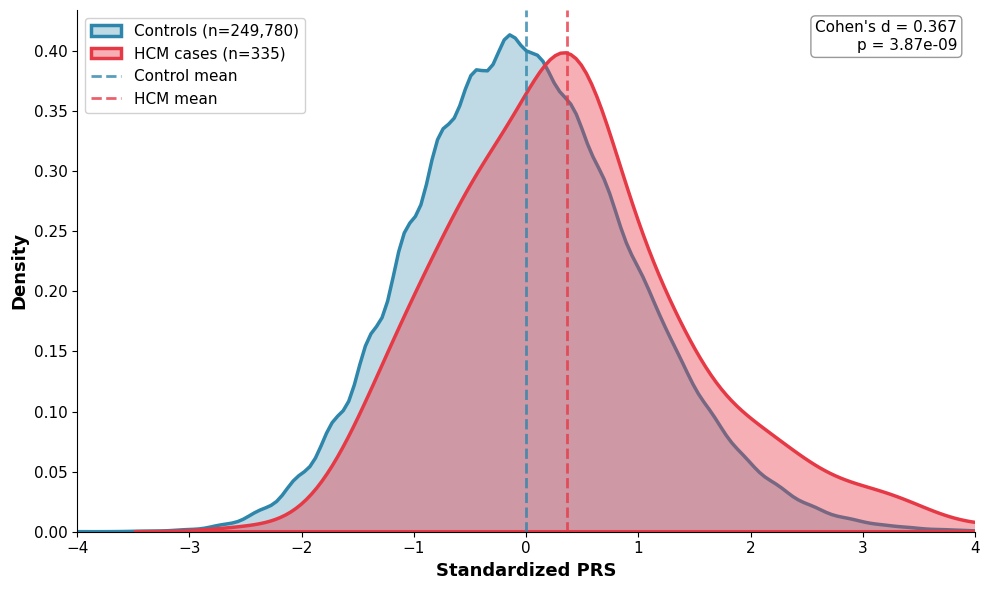

In [75]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate percentiles for HCM patients relative to controls
hcm_prs_scores['percentile'] = hcm_prs_scores['PRS'].apply(
    lambda x: stats.percentileofscore(control_prs_scores['PRS'], x)
)

# Summary statistics
print("PRS COMPARISON: HCM CASES VS CONTROLS")

print(f"\nControls (n={len(control_prs_scores):,}):")
print(f"  Raw PRS: {control_mean:.4f} ± {control_std:.4f}")
print(f"  Standardized: 0.0000 ± 1.0000")

hcm_mean_raw = hcm_prs_scores['PRS'].mean()
hcm_std_raw = hcm_prs_scores['PRS'].std()
hcm_mean_std = hcm_prs_scores['PRS_standardized'].mean()
hcm_std_std = hcm_prs_scores['PRS_standardized'].std()

print(f"\nHCM cases (n={len(hcm_prs_scores):,}):")
print(f"  Raw PRS: {hcm_mean_raw:.4f} ± {hcm_std_raw:.4f}")
print(f"  Standardized: {hcm_mean_std:.4f} ± {hcm_std_std:.4f}")

print(f"\nEffect size (Cohen's d): {hcm_mean_std:.4f}")

# Statistical test
t_stat, p_value = stats.ttest_ind(
    hcm_prs_scores['PRS'], 
    control_prs_scores['PRS'],
    equal_var=False
)
print(f"\nWelch's t-test:")
print(f"  t = {t_stat:.4f}")
print(f"  p = {p_value:.2e}")

# Percentile enrichment analysis
print(f"\nHCM enrichment in control PRS percentiles:")
for pct in [50, 75, 90, 95, 99]:
    threshold = np.percentile(control_prs_scores['PRS'], pct)
    n_above = (hcm_prs_scores['PRS'] > threshold).sum()
    pct_above = (n_above / len(hcm_prs_scores)) * 100
    expected = 100 - pct
    enrichment = pct_above / expected if expected > 0 else np.inf
    print(f"  >{pct}th: {n_above}/{len(hcm_prs_scores)} ({pct_above:.1f}%) [expected {expected}%, {enrichment:.2f}x]")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Density plots
sns.kdeplot(
    data=control_prs_scores['PRS_standardized'], 
    ax=ax, 
    color='#2E86AB',
    linewidth=2.5, 
    label=f'Controls (n={len(control_prs_scores):,})', 
    fill=True, 
    alpha=0.3
)

sns.kdeplot(
    data=hcm_prs_scores['PRS_standardized'], 
    ax=ax, 
    color='#E63946',
    linewidth=2.5, 
    label=f'HCM cases (n={len(hcm_prs_scores):,})', 
    fill=True, 
    alpha=0.4
)

# Mean lines
ax.axvline(0, color='#2E86AB', linestyle='--', linewidth=2, alpha=0.8, label='Control mean')
ax.axvline(hcm_mean_std, color='#E63946', linestyle='--', linewidth=2, alpha=0.8, label='HCM mean')

# Formatting
ax.set_xlabel('Standardized PRS', fontsize=13, fontweight='bold')
ax.set_ylabel('Density', fontsize=13, fontweight='bold')
ax.set_xlim(-4, 4)
ax.tick_params(labelsize=11)

# Legend and p-value
ax.legend(fontsize=11, loc='upper left', frameon=True, framealpha=0.9)
ax.text(
    0.98, 0.98, 
    f"Cohen's d = {hcm_mean_std:.3f}\np = {p_value:.2e}", 
    transform=ax.transAxes, 
    fontsize=11,
    verticalalignment='top', 
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
output_path = f"{OUTPUT_DIR}/prs/prs_distribution_cases_vs_controls.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

## 3. Pathogenic Variant Carrier Identification

Extracts genotype dosages for the 24-gene HCM panel (Invitae panel,
pathogenic variants per ClinVar), flips ALT-coded dosages to REF (pathogenic
alleles are coded as REF in the source files), and classifies carriers
(dosage > 0 for any panel variant).

In [76]:
import pandas as pd
import subprocess
import concurrent.futures
from pathlib import Path

#Configuration
OUTPUT_DIR = "/home/jupyter/prs_hcm_experiment/variant_counts"
GENE_CSV_DIR = "/home/jupyter/prs_hcm_experiment/gene_panel"
HCM_KEEP_FILE = '/home/jupyter/prs_hcm_experiment/hcm_cohort.keep'

MAX_WORKERS = 4

# Gene to chromosome mapping
GENE_CHROM_MAP = {
    'ACADVL': 17, 'ACTC1': 15, 'ACTN2': 1, 'MYH6': 14, 'AGL': 1,
    'CPT2': 1, 'ALPK3': 15, 'CACNA1C': 12, 'LAMP2': 23, 'MYL2': 12,
    'ELAC2': 17, 'FLNC': 7, 'MTO1': 6, 'TCAP': 17, 'MYH7': 14,
    'TPM1': 15, 'PRKAG2': 2, 'MYL3': 3, 'TNNI3': 19, 'TNNT2': 1,
    'TNNC1': 3, 'MYBPC3': 11, 'BRAF': 7, 'TBX1': 22
}

# Load HCM cohort
hcm_ids = pd.read_csv(HCM_KEEP_FILE, sep=r'\s+', header=None, names=['IID', 'FID'])
hcm_iid_set = set(hcm_ids['IID'].astype(str))
print(f"Loaded {len(hcm_ids):,} HCM samples\n")

# Fing gene variant files
csv_files = sorted(Path(GENE_CSV_DIR).glob("*.csv"))
print(f"Found {len(csv_files)} gene variant CSV files\n")
print("=" * 80)

# Process one gene (runs in a worker thread)
def process_gene(csv_file):
    gene_name = csv_file.stem.strip()
    log = [f"\nProcessing: {gene_name}"]
    empty = {'gene': gene_name, 'summary': None, 'all_carriers_long': [], 'hcm_carriers_long': []}

    if gene_name not in GENE_CHROM_MAP:
        log.append(f"WARNING: Skipping {gene_name} - not in gene-chromosome mapping")
        return {**empty, 'status': 'skipped', 'log': log}

    chrom = GENE_CHROM_MAP[gene_name]
    log.append(f"  (chr{chrom})")
    log.append("-" * 80)

    # Load variant list
    try:
        variants_df = pd.read_csv(csv_file, header=None)
        variant_ids = variants_df[0].dropna().astype(str).tolist()
        n_variants = len(variant_ids)
        log.append(f"  Loaded {n_variants} variant(s) from {csv_file.name}")
    except Exception as e:
        log.append(f"  ERROR reading {csv_file.name}: {e}")
        return {**empty, 'status': 'error', 'log': log}
        
    # Extract genotypes using PLINK2
    chrom_dir = f"{CHROM_BASE_PATH}/chrom-{chrom}/postproc-pgen"
    pfile_prefix = f"{chrom_dir}/dragen"
    output_prefix = f"{OUTPUT_DIR}/{gene_name}_dosages"

    cmd = [
        PLINK2_PATH,
        "--pfile", pfile_prefix,
        "--extract", str(csv_file),
        "--recode", "A",
        "--out", output_prefix
    ]

    log.append(f"  Extracting dosages from {pfile_prefix}...")
    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        log.append(f"  ERROR: PLINK2 failed")
        log.append(f"  {result.stderr}")
        return {**empty, 'status': 'error', 'log': log}

    # Parse PLINK2 output for extracted variant count
    extracted_count = 0
    for line in result.stdout.split('\n'):
        if 'variants remaining' in line.lower() and 'after main filters' in line.lower():
            try:
                extracted_count = int(line.split()[0])
                break
            except ValueError:
                pass

    if extracted_count == 0:
        log.append(f"  WARNING: No variants found in file - skipping {gene_name}")
        return {**empty, 'status': 'skipped', 'log': log}

    log.append(f"  Extracted {extracted_count}/{n_variants} variants")

    # Load and process dosages
    dosage_file = f"{output_prefix}.raw"

    try:
        dosages = pd.read_csv(dosage_file, sep=r'\s+')
    except Exception as e:
        log.append(f"  ERROR loading dosage file: {e}")
        return {**empty, 'status': 'error', 'log': log}

    log.append(f"  Loaded dosages: {dosages.shape[0]:,} samples x {dosages.shape[1]} columns")

    # Identify variant columns
    standard_cols = ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE']
    variant_cols = [col for col in dosages.columns if col not in standard_cols]

    if len(variant_cols) == 0:
        log.append(f"  WARNING: No variant columns found - skipping {gene_name}")
        return {**empty, 'status': 'skipped', 'log': log}

    log.append(f"  Variants in dosage file: {len(variant_cols)}")

    # Invert dosages (ALT -> REF, since pathogenic alleles are coded as REF)
    for col in variant_cols:
        dosages[col] = 2 - dosages[col]

    # Calculate carrier status
    dosages['total_dosage'] = dosages[variant_cols].sum(axis=1)
    dosages['is_carrier'] = (dosages['total_dosage'] > 0).astype(int)
    dosages['num_variants'] = (dosages[variant_cols] > 0).sum(axis=1)

    dosages['IID'] = dosages['IID'].astype(str)
    dosages['is_hcm'] = dosages['IID'].isin(hcm_iid_set).astype(int)

    # Calculate statistics
    all_samples = dosages
    hcm_samples = dosages[dosages['is_hcm'] == 1]

    n_all_carriers = all_samples['is_carrier'].sum()
    pct_all = (n_all_carriers / len(all_samples)) * 100

    n_hcm = len(hcm_samples)
    n_hcm_carriers = hcm_samples['is_carrier'].sum()
    pct_hcm = (n_hcm_carriers / n_hcm) * 100 if n_hcm > 0 else 0

    enrichment = pct_hcm / pct_all if pct_all > 0 else 0

    log.append(f"\n  RESULTS:")
    log.append(f"    All samples (n={len(all_samples):,}): {n_all_carriers:,} carriers ({pct_all:.4f}%)")
    log.append(f"    HCM cohort (n={n_hcm:,}): {n_hcm_carriers:,} carriers ({pct_hcm:.2f}%)")
    if enrichment > 0:
        log.append(f"    Enrichment: {enrichment:.2f}x")

    # Save wide-format carrier files
    carrier_cols = ['FID', 'IID', 'total_dosage', 'num_variants']

    all_carriers_wide = all_samples[all_samples['is_carrier'] == 1][
        carrier_cols + ['is_hcm'] + variant_cols
    ]
    hcm_carriers_wide = hcm_samples[hcm_samples['is_carrier'] == 1][
        carrier_cols + variant_cols
    ]

    all_carriers_wide.to_csv(f"{OUTPUT_DIR}/{gene_name}_all_carriers_wide.tsv", sep='\t', index=False)
    hcm_carriers_wide.to_csv(f"{OUTPUT_DIR}/{gene_name}_hcm_carriers_wide.tsv", sep='\t', index=False)

    # Build long-format records
    gene_all_carriers_long = []
    for _, row in all_samples[all_samples['is_carrier'] == 1].iterrows():
        for var_col in variant_cols:
            dosage_val = row[var_col]
            if dosage_val > 0:
                gene_all_carriers_long.append({
                    'Gene': gene_name, 'IID': row['IID'], 'FID': row['FID'],
                    'is_hcm': row['is_hcm'], 'variant_id': var_col.replace('_', ':'),
                    'dosage': int(dosage_val), 'genotype': 'Het' if dosage_val == 1 else 'Hom'
                })

    gene_hcm_carriers_long = []
    for _, row in hcm_samples[hcm_samples['is_carrier'] == 1].iterrows():
        for var_col in variant_cols:
            dosage_val = row[var_col]
            if dosage_val > 0:
                gene_hcm_carriers_long.append({
                    'Gene': gene_name, 'IID': row['IID'], 'FID': row['FID'],
                    'variant_id': var_col.replace('_', ':'),
                    'dosage': int(dosage_val), 'genotype': 'Het' if dosage_val == 1 else 'Hom'
                })

    summary_row = {
        'Gene': gene_name, 'Chromosome': chrom, 'Variants_Input': n_variants,
        'Variants_Found': extracted_count, 'All_N': len(all_samples),
        'All_Carriers': n_all_carriers, 'All_Carrier_Pct': pct_all,
        'HCM_N': n_hcm, 'HCM_Carriers': n_hcm_carriers,
        'HCM_Carrier_Pct': pct_hcm, 'Enrichment': enrichment
    }

    return {'gene': gene_name, 'status': 'ok', 'log': log, 'summary': summary_row,
            'all_carriers_long': gene_all_carriers_long, 'hcm_carriers_long': gene_hcm_carriers_long}


# Run across genes concurrently
summary_results = []
all_carriers_long = []
hcm_carriers_long = []

with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(process_gene, csv_file): csv_file for csv_file in csv_files}
    for future in concurrent.futures.as_completed(futures):
        result = future.result()
        print('\n'.join(result['log']))
        if result['summary'] is not None:
            summary_results.append(result['summary'])
        all_carriers_long.extend(result['all_carriers_long'])
        hcm_carriers_long.extend(result['hcm_carriers_long'])

# Save summary

summary_df = pd.DataFrame(summary_results)
summary_output = f"{OUTPUT_DIR}/summary_all_genes.tsv"
summary_df.to_csv(summary_output, sep='\t', index=False)
print(f"\nSaved gene-level summary: {summary_output}")

# Save long-format files
if all_carriers_long:
    all_long_df = pd.DataFrame(all_carriers_long)
    all_long_df = all_long_df.sort_values(['IID', 'Gene', 'variant_id'])
    all_long_output = f"{OUTPUT_DIR}/all_carriers_long_format.tsv"
    all_long_df.to_csv(all_long_output, sep='\t', index=False)

    print(f"\nALL COHORT (long format):")
    print(f"  {len(all_long_df):,} person-variant records")
    print(f"  {all_long_df['IID'].nunique():,} unique carriers")

if hcm_carriers_long:
    hcm_long_df = pd.DataFrame(hcm_carriers_long)
    hcm_long_df = hcm_long_df.sort_values(['IID', 'Gene', 'variant_id'])
    hcm_long_output = f"{OUTPUT_DIR}/hcm_carriers_long_format.tsv"
    hcm_long_df.to_csv(hcm_long_output, sep='\t', index=False)

    print(f"\nHCM COHORT (long format):")
    print(f"  {len(hcm_long_df):,} person-variant records")
    print(f"  {hcm_long_df['IID'].nunique():,} unique HCM carriers")

Loaded 335 HCM samples

Found 24 gene variant CSV files


Processing: ACTC1
  (chr15)
--------------------------------------------------------------------------------
  Loaded 2 variant(s) from ACTC1.csv
  Extracting dosages from /home/jupyter/gcs/chrom-15/postproc-pgen/dragen...

Processing: ACADVL
  (chr17)
--------------------------------------------------------------------------------
  Loaded 47 variant(s) from  ACADVL.csv
  Extracting dosages from /home/jupyter/gcs/chrom-17/postproc-pgen/dragen...
  Extracted 16/47 variants
  Loaded dosages: 250,115 samples x 22 columns
  Variants in dosage file: 16

  RESULTS:
    All samples (n=250,115): 233 carriers (0.0932%)
    HCM cohort (n=335): 0 carriers (0.00%)

Processing: ALPK3
  (chr15)
--------------------------------------------------------------------------------
  Loaded 54 variant(s) from ALPK3.csv
  Extracting dosages from /home/jupyter/gcs/chrom-15/postproc-pgen/dragen...
  Extracted 25/54 variants
  Loaded dosages: 250,115 sa

## 4. HCM Master Cohort Table

This section creates the final analytical dataset by integrating:
1. **Cohort definitions** (HCM cases, GenPop carriers/non-carriers)
2. **Genetic data** (carrier status, PRS scores)
3. **Demographics** (age, sex)
4. **Clinical outcomes** (Major Adverse Cardiovascular Events (MACE), interventions, death)

The master cohort table serves as the single source of truth for all downstream analyses.

### 4a. Assemble Cohort + Carrier Status + PRS + Demographics

**Purpose:** Build the foundational master table containing:
- **Genotyped samples** from BioVU Biobank 
- **HCM case status** from diagnosis table
- **Last visit date** for censoring support
- **Carrier status** for pathogenic variants in sarcomere genes
- **PRS scores** with percentiles and quartiles
- **Demographics** (age, sex) from OMOP person table
- **Cohort group assignment:**
  - `HCM Carrier`: HCM diagnosis + pathogenic variant
  - `HCM Non-Carrier`: HCM diagnosis + no pathogenic variant
  - `GenPop Carrier`: No HCM diagnosis + pathogenic variant
  - `GenPop Non-Carrier`: No HCM diagnosis + no pathogenic variant

**Output:** `hcm_master_cohort` table uploaded to BigQuery scratch dataset

In [77]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
import glob

# Initialize BigQuery client
PROJECT_ID = "nb-tre-dev-2-483522"
SCRATCH_DATASET_ID = "hcm_analysis_final"

client = bigquery.Client(project=PROJECT_ID)

# Create scratch dataset if it doesn't exist
scratch_dataset_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}"
scratch_dataset = bigquery.Dataset(scratch_dataset_id)
scratch_dataset.location = "US"

try:
    scratch_dataset = client.create_dataset(scratch_dataset, timeout=30)
    print(f" Created scratch dataset: {scratch_dataset_id}")
except Exception as e:
    if "Already Exists" in str(e):
        print(f" Scratch dataset already exists: {scratch_dataset_id}")
    else:
        print(f" Error creating dataset: {e}")
        
print(f"Working Configuration:")
print(f"  Project: {PROJECT_ID}")
print(f"  Scratch Dataset: {SCRATCH_DATASET_ID}")
print(f"  Location: US")

 Scratch dataset already exists: nb-tre-dev-2-483522.hcm_analysis_final
Working Configuration:
  Project: nb-tre-dev-2-483522
  Scratch Dataset: hcm_analysis_final
  Location: US


In [78]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "nb-tre-dev-2-483522"
OMOP_DATASET_ID = "nb-tre-dev-2-483522.omop_dataset_v2026_1_1"
OUTPUT_DIR = "/home/jupyter/prs_hcm_experiment"

client = bigquery.Client(project=PROJECT_ID)

# 1. HCM diagnosis detail
hcm_diagnosis_df = hcm_cases_final[["person_id", "n_distinct_dates", "first_hcm_date", "last_hcm_date"]].copy()
hcm_diagnosis_df = hcm_diagnosis_df.rename(columns={"n_distinct_dates": "n_hcm_diagnosis_codes"})
hcm_diagnosis_df["person_id"] = hcm_diagnosis_df["person_id"].astype(str)
print(f"HCM cases: {len(hcm_diagnosis_df):,}")

# 2. Genotyped sample universe + case flag
# Keep only real patient IDs (R followed by numbers)
mask = psam_df["IID"].astype(str).str.match(r'^R\d+$')
psam_df = psam_df[mask].copy()
master = psam_df[["FID", "IID"]].copy()
master["person_id"] = master["IID"].astype(str)

hcm_ids = set(hcm_diagnosis_df["person_id"])
master["is_hcm_case"] = master["person_id"].isin(hcm_ids)
master = master.merge(hcm_diagnosis_df, on="person_id", how="left")

# 3. Carrier status
carriers_long = pd.read_csv(f"{OUTPUT_DIR}/variant_counts/all_carriers_long_format.tsv", sep="\t")
carriers_long["person_id"] = carriers_long["IID"].astype(str)

carrier_summary = (
    carriers_long.groupby("person_id")
    .agg(
        carrier_genes=("Gene", lambda g: ";".join(sorted(set(g)))),
        n_variants=("variant_id", "nunique"),
        variant_ids=("variant_id", lambda v: ";".join(sorted(set(v)))),  # Keep variant IDs
    )
    .reset_index()
)
carrier_summary["is_carrier"] = True

master = master.merge(carrier_summary, on="person_id", how="left")
master["is_carrier"] = master["is_carrier"].notna()  # True if merged, False if not
master["n_variants"] = master["n_variants"].fillna(0).astype(int)

# Fill empty strings for non-carriers
for col in ["carrier_genes", "variant_ids"]:
    master[col] = master[col].fillna("")

# 4. PRS - standardized against non-HCM controls
prs_df = pd.read_csv(f"{OUTPUT_DIR}/prs/prs_scores_all_samples.tsv", sep="\t")
prs_df = prs_df.rename(columns={"IID": "person_id", "PRS": "prs"})
prs_df["person_id"] = prs_df["person_id"].astype(str)

# Standardize against controls
control_mask = ~prs_df["person_id"].isin(hcm_ids)
control_mean = prs_df.loc[control_mask, "prs"].mean()
control_std = prs_df.loc[control_mask, "prs"].std()
prs_df["prs_standardized"] = (prs_df["prs"] - control_mean) / control_std

# Create risk categories
prs_df["prs_quartile"] = pd.qcut(prs_df["prs_standardized"], 4, labels=["Q1", "Q2", "Q3", "Q4"])

master = master.merge(
    prs_df[["person_id", "prs", "prs_standardized", "prs_quartile"]],
    on="person_id", how="left",
)

# 5. Demographics
# Upload person_ids to temp table to avoid query size limits
temp_table_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.temp_master_person_ids"

# Create temp table with person_ids
person_ids_df = master[["person_id"]].drop_duplicates()
job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
)
client.load_table_from_dataframe(person_ids_df, temp_table_id, job_config=job_config).result()
print(f"Uploaded {len(person_ids_df):,} person_ids to temp table")

# Query using the temp table
query_demographics = f"""
SELECT
  p.person_id,
  DATE(p.birth_datetime) AS birth_date,
  p.gender_concept_id,
  CASE 
    WHEN p.gender_concept_id = 8507 THEN 'Male'
    WHEN p.gender_concept_id = 8532 THEN 'Female'
    ELSE 'Other/Unknown'
  END AS sex
FROM `{OMOP_DATASET_ID}.person` p
INNER JOIN `{temp_table_id}` t ON p.person_id = t.person_id
"""
demo_df = client.query(query_demographics).to_dataframe()
demo_df["person_id"] = demo_df["person_id"].astype(str)

# Clean up temp table
client.delete_table(temp_table_id, not_found_ok=True)
print("Temp table deleted")

master = master.merge(demo_df, on="person_id", how="left")

# Calculate age
master["birth_date"] = pd.to_datetime(master["birth_date"])
master["first_hcm_date"] = pd.to_datetime(master["first_hcm_date"])

# Calculate age at HCM diagnosis (for cases only)
master["age_at_hcm_diagnosis"] = None
mask = master["is_hcm_case"]
master.loc[mask, "age_at_hcm_diagnosis"] = (
    (master.loc[mask, "first_hcm_date"] - master.loc[mask, "birth_date"]).dt.days / 365.25
).round(1)

# 6. Derived cohort grouping
master["cohort_group"] = (
    master["is_hcm_case"].map({True: "HCM", False: "GenPop"})
    + " "
    + master["is_carrier"].map({True: "Carrier", False: "Non-Carrier"})
)

# 7. Summary statistics before upload
print("MASTER COHORT SUMMARY")
print(f"\nTotal individuals: {len(master):,}")

print(f"\nCohort breakdown:")
print(master["cohort_group"].value_counts().sort_index())

print(f"\nCarrier statistics:")
print(f"  Total carriers: {master['is_carrier'].sum():,}")
print(f"  Single variant: {(master['n_variants'] == 1).sum():,}")
print(f"  Multiple variants (n≥2): {(master['n_variants'] >= 2).sum():,}")

print(f"\nDemographics:")
print(f"  Sex distribution:")
print(master['sex'].value_counts())

if master['is_hcm_case'].sum() > 0:
    hcm_mask = master['is_hcm_case']
    print(f"\n  HCM cases - Mean age at diagnosis: {master.loc[hcm_mask, 'age_at_hcm_diagnosis'].mean():.1f} years (SD: {master.loc[hcm_mask, 'age_at_hcm_diagnosis'].std():.1f})")
    print(f"  HCM cases - Median age at diagnosis: {master.loc[hcm_mask, 'age_at_hcm_diagnosis'].median():.1f} years")

HCM cases: 1,641
Uploaded 250,105 person_ids to temp table
Temp table deleted
MASTER COHORT SUMMARY

Total individuals: 250,105

Cohort breakdown:
cohort_group
GenPop Carrier          1510
GenPop Non-Carrier    248260
HCM Carrier               48
HCM Non-Carrier          287
Name: count, dtype: int64

Carrier statistics:
  Total carriers: 1,558
  Single variant: 1,553
  Multiple variants (n≥2): 5

Demographics:
  Sex distribution:
sex
Female    143949
Male      105945
Name: count, dtype: int64

  HCM cases - Mean age at diagnosis: 53.3 years (SD: 17.7)
  HCM cases - Median age at diagnosis: 54.9 years


In [79]:
# 8. Upload to BigQuery
# Convert categorical columns to strings for BigQuery
master["prs_quartile"] = master["prs_quartile"].astype(str)

# Convert datetime columns to date-only (removes time component)
for col in ["birth_date", "first_hcm_date", "last_hcm_date", "last_visit_date"]:
    if col in master.columns:
        master[col] = pd.to_datetime(master[col]).dt.date
        
table_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_master_cohort"
job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE", autodetect=True)
job = client.load_table_from_dataframe(master, table_id, job_config=job_config)
job.result()
print(f" Uploaded {len(master):,} rows to {table_id}")

 Uploaded 250,105 rows to nb-tre-dev-2-483522.hcm_analysis_final.hcm_master_cohort


In [80]:
# Quick overview of the table structure
print("Column names and types:")
print(master.dtypes)

print(f"\nTable shape: {master.shape[0]:,} rows × {master.shape[1]} columns")

print("\nColumn list:")
print(master.columns.tolist())

# Preview first few rows
print("\nFirst 5 rows:")
master.head()

Column names and types:
FID                       object
IID                       object
person_id                 object
is_hcm_case                 bool
n_hcm_diagnosis_codes    float64
first_hcm_date            object
last_hcm_date             object
carrier_genes             object
n_variants                 int64
variant_ids               object
is_carrier                  bool
prs                      float64
prs_standardized         float64
prs_quartile              object
birth_date                object
gender_concept_id          Int64
sex                       object
age_at_hcm_diagnosis      object
cohort_group              object
dtype: object

Table shape: 250,105 rows × 19 columns

Column list:
['FID', 'IID', 'person_id', 'is_hcm_case', 'n_hcm_diagnosis_codes', 'first_hcm_date', 'last_hcm_date', 'carrier_genes', 'n_variants', 'variant_ids', 'is_carrier', 'prs', 'prs_standardized', 'prs_quartile', 'birth_date', 'gender_concept_id', 'sex', 'age_at_hcm_diagnosis', 'cohort_g

,FID,IID,person_id,is_hcm_case,n_hcm_diagnosis_codes,first_hcm_date,last_hcm_date,carrier_genes,n_variants,variant_ids,is_carrier,prs,prs_standardized,prs_quartile,birth_date,gender_concept_id,sex,age_at_hcm_diagnosis,cohort_group
0,R200000348,R200000348,R200000348,False,NaN,NaT,NaT,,0,,False,-2.997846,1.647606,Q4,1937-03-06,8507,Male,None,GenPop Non-Carrier
1,R200000649,R200000649,R200000649,False,NaN,NaT,NaT,,0,,False,-4.446816,-0.638107,Q2,1971-05-09,8507,Male,None,GenPop Non-Carrier
2,R200001537,R200001537,R200001537,False,NaN,NaT,NaT,,0,,False,-2.983124,1.670830,Q4,1990-05-06,8532,Female,None,GenPop Non-Carrier
3,R200002217,R200002217,R200002217,False,NaN,NaT,NaT,,0,,False,-4.202286,-0.252367,Q2,1983-08-03,8507,Male,None,GenPop Non-Carrier
4,R200003540,R200003540,R200003540,False,NaN,NaT,NaT,,0,,False,-4.349978,-0.485347,Q2,1959-01-16,8507,Male,None,GenPop Non-Carrier


### 4b. Event Mapping Table
**Purpose:** Create a concept-to-outcome mapping table that links OMOP standard concept IDs to clinically meaningful event categories for:
1. **MACE outcomes** (conditions): Heart failure, ventricular arrhythmia, cardiac arrest / sudden death, stroke, etc.
2. **Interventions** (procedures): ICD implantation, cardiac ablation, septal reduction, heart transplant, etc.

**Approach:**
- Discover candidate concepts via a cohort-independent vocabulary search (matching `concept_name` against clinical search terms), not restricted to concepts already observed in the cohort
- Upload to staging tables: `staging_cardiac_conditions` and `staging_cardiac_procedures`
- Filter out non-specific concepts (exclusion lists based on clinical review)
- Create unified `event_mapping` table with columns:
  - `concept_id`: OMOP standard concept ID
  - `concept_name`: Human-readable concept name
  - `event_category`: Clinical outcome group (e.g., "Heart Failure", "ICD Implantation")
  - `model_type`: MACE or Intervention
  - `source_type`: condition or procedure

**Output:** `event_mapping` table for linking condition/procedure clinical events to outcomes.

### 4c. `has_hcm` Flag 

**Purpose:** `is_hcm_case` reflects strict cohort-eligibility criteria (inclusion/exclusion codes, genotype availability, follow-up requirements, etc.) - it answers "who qualifies for our study population." Penetrance analysis asks a different question: *of everyone who carries a given pathogenic variant, what fraction ever developed the HCM phenotype?* Restricting that calculation to `is_hcm_case` would systematically undercount true diagnoses among carriers, since someone can have a real HCM diagnosis and still be excluded from the strict cohort for reasons unrelated to disease status (e.g., insufficient follow-up).

`has_hcm` is therefore a broader, independent flag: **≥2 HCM-associated ICD diagnosis codes on ≥2 distinct calendar dates**, and unlike the MACE/intervention flags, it is **not restricted to events after baseline** - it captures whether the diagnosis was ever recorded, at any point in the person's record.

**Scoping note:** `has_hcm` is validated and used for penetrance/age-of-onset analyses (KM/Cox), which anchor directly on birth date and diagnosis-evidence dates. It is *not* used to expand the MACE/Intervention/Death outcome analyses or the four `cohort_group` categories — those remain scoped to `is_hcm_case` only, since `baseline_date` (used to anchor those outcome windows) is not currently computed for `has_hcm`-only cases. Expanding those analyses to the full `has_hcm` population was considered and intentionally deferred, to avoid diluting the strict-diagnosis outcome cohort with the more loosely-defined `has_hcm` group.

In [81]:
# --- has_hcm flag: minimal criteria for penetrance analysis ---
# Definition: ≥2 HCM primary ICD codes on ≥2 distinct dates,
# independent of cohort inclusion/exclusion criteria (is_hcm_case).
import pandas as pd
HCM_PRIMARY_ICD10 = ["I42.1", "I42.2"]
HCM_PRIMARY_ICD9 = ["425.1", "425.11", "425.18"]
has_hcm_codes = HCM_PRIMARY_ICD10 + HCM_PRIMARY_ICD9

has_hcm_concept_ids = (
    concept_map_df.loc[concept_map_df["source_code"].isin(has_hcm_codes), "standard_concept_id"]
    .dropna().astype(int).unique().tolist()
)
print(f"has_hcm primary concept_ids (n={len(has_hcm_concept_ids)}): {has_hcm_concept_ids}")

has_hcm_events_df = find_events_across_tables(
    codes=has_hcm_codes,
    concept_ids=has_hcm_concept_ids,
    dataset=OMOP_DATASET_ID,
    label="has_hcm minimal-criteria diagnosis events",
)

# capture the date of the 2nd qualifying (the date the ≥2-distinct-dates criteria was first met)
has_hcm_summary = (
    has_hcm_events_df
    .sort_values(["person_id", "event_date"])
    .groupby("person_id")["event_date"]
    .agg(n_distinct_dates="nunique", first_hcm_flag_date=lambda x: sorted(x.unique())[1] if x.nunique() >= 2 else pd.NaT)
    .reset_index()
)
has_hcm_summary["has_hcm"] = has_hcm_summary["n_distinct_dates"] >= 2

print(f"Persons with ≥1 qualifying event: {len(has_hcm_summary):,}")
print(f"Persons meeting has_hcm (≥2 distinct dates): {has_hcm_summary['has_hcm'].sum():,}")

has_hcm_flags_df = has_hcm_summary[["person_id", "has_hcm", "first_hcm_flag_date"]]

has_hcm primary concept_ids (n=2): [4124693, 316428]
has_hcm minimal-criteria diagnosis events: 138,401 events across 6,103 persons
source_table
condition_occurrence    138401
Name: count, dtype: int64
Persons with ≥1 qualifying event: 6,103
Persons meeting has_hcm (≥2 distinct dates): 3,772


In [82]:
has_hcm_table_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.has_hcm_flags"
job = client.load_table_from_dataframe(
    has_hcm_flags_df,
    has_hcm_table_id,
    job_config=bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE"),
)
job.result()
print(f"Uploaded has_hcm_flags_df to {has_hcm_table_id} ({len(has_hcm_flags_df):,} rows)")

Uploaded has_hcm_flags_df to nb-tre-dev-2-483522.hcm_analysis_final.has_hcm_flags (6,103 rows)


In [83]:
# --- has_hcm + first_hcm_flag_date ---

# Add both columns
client.query(f"""
ALTER TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_master_cohort`
ADD COLUMN IF NOT EXISTS has_hcm BOOL,
ADD COLUMN IF NOT EXISTS first_hcm_flag_date DATE
""").result()

# Populate both via UPDATE, joining against has_hcm_flags table
client.query(f"""
UPDATE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_master_cohort` mc
SET has_hcm = COALESCE(hh.has_hcm, FALSE),
    first_hcm_flag_date = hh.first_hcm_flag_date
FROM `{has_hcm_table_id}` hh
WHERE mc.person_id = hh.person_id
""").result()

# For anyone with no matching row in has_hcm_flags (no qualifying events at all)
client.query(f"""
UPDATE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_master_cohort`
SET has_hcm = FALSE
WHERE has_hcm IS NULL
""").result()

print("has_hcm and first_hcm_flag_date added and populated")

has_hcm and first_hcm_flag_date added and populated


### 4d. `last_visit_date` (Censoring Date)

**Purpose:** Time-to-event analyses (Kaplan-Meier/Cox Model) for HCM penetrance need a censoring date for anyone who has not (yet) developed HCM - i.e., the age up to which we can say "this person was followed and remained disease-free." Without this, non-cases would have no defined endpoint for survival analysis.

`last_visit_date` is defined as the most recent recorded date across all clinical activity for a person - condition, procedure, measurement, and observation records - independent of diagnosis or cohort status. This makes it a general-purpose "last known point of observation" usable for censoring anyone in the cohort, not just non-cases (cases use their diagnosis-evidence date as the event time instead; `last_visit_date` is simply unused for them).

**Coverage note:** anyone with zero recorded clinical activity across all four source tables will have `last_visit_date = NULL` and cannot be used in survival analyses (no valid censoring date) — check `COUNT(*) WHERE last_visit_date IS NULL` before running time-to-event analyses to confirm this affects only a small fraction of the cohort.

In [84]:
last_visit_query = f"""
SELECT person_id, MAX(event_date) AS last_visit_date
FROM (
  SELECT person_id, condition_start_date AS event_date FROM `{OMOP_DATASET_ID}.condition_occurrence`
  UNION ALL
  SELECT person_id, procedure_date AS event_date FROM `{OMOP_DATASET_ID}.procedure_occurrence`
  UNION ALL
  SELECT person_id, measurement_date AS event_date FROM `{OMOP_DATASET_ID}.measurement`
  UNION ALL
  SELECT person_id, observation_date AS event_date FROM `{OMOP_DATASET_ID}.observation`
)
WHERE event_date IS NOT NULL AND event_date <= CURRENT_DATE()
GROUP BY person_id
"""
last_visit_df = client.query(last_visit_query).to_dataframe()
print(f"Pulled last_visit_date for {len(last_visit_df):,} persons")

# Upload to scratch dataset, same pattern as has_hcm_flags_df
last_visit_table_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.last_visit_flags"
job = client.load_table_from_dataframe(
    last_visit_df,
    last_visit_table_id,
    job_config=bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE"),
)
job.result()
print(f"Uploaded last_visit_flags to {last_visit_table_id}")

Pulled last_visit_date for 3,965,498 persons
Uploaded last_visit_flags to nb-tre-dev-2-483522.hcm_analysis_final.last_visit_flags


### 4e. Extract Clinical Events from OMOP

**Purpose:** Extract all relevant cardiac events for cohort members from OMOP clinical tables, filtered to only the concepts in our event mapping.

**Data sources:**
1. **condition_occurrence** -> MACE outcomes (heart failure, arrhythmias, etc.)
2. **procedure_occurrence** -> Interventions (ICD, ablation, transplant, etc.)
3. **death** -> All-cause mortality
4. **death (cause_source_value)** -> Cardiac Arrest / Sudden Death, sourced separately from cause-of-death text (ICD code `I46%`), since `death.cause_concept_id` is largely unpopulated in this dataset and cannot be joined against `event_mapping` the way conditions/procedures are

**Output tables:**
- `condition_events`: Cardiac conditions with dates
- `procedure_events`: Cardiac procedures with dates  
- `death_events`: Death dates
- `cardiac_arrest_death_events`: Deaths with a cardiac-arrest/sudden-death cause code, keyed by `cause_source_value` rather than `concept_id`

In [40]:
PROJECT_ID = "nb-tre-dev-2-483522"
OMOP_DATASET_ID = "nb-tre-dev-2-483522.omop_dataset_v2026_1_1"
SCRATCH_DATASET_ID = "hcm_analysis_final"
OUTPUT_DIR = "/home/jupyter/prs_hcm_experiment/clinical_analysis"


cardiac_search_terms_condition = """
STRUCT('Heart failure' AS search_term, 'Heart Failure' AS event_category),
STRUCT('Cardiac failure' AS search_term, 'Heart Failure' AS event_category),
STRUCT('Congestive heart failure' AS search_term, 'Heart Failure' AS event_category),
STRUCT('Ventricular tachycardia' AS search_term, 'Ventricular Arrhythmia' AS event_category),
STRUCT('Ventricular fibrillation' AS search_term, 'Ventricular Arrhythmia' AS event_category),
STRUCT('Cardiac arrest' AS search_term, 'Cardiac Arrest / Sudden Death' AS event_category),
STRUCT('Sudden cardiac death' AS search_term, 'Cardiac Arrest / Sudden Death' AS event_category),
STRUCT('Atrial fibrillation' AS search_term, 'Atrial Fibrillation' AS event_category),
STRUCT('Atrial flutter' AS search_term, 'Atrial Fibrillation' AS event_category),
STRUCT('Cardiogenic shock' AS search_term, 'Cardiogenic Shock' AS event_category),
STRUCT('Stroke' AS search_term, 'Stroke' AS event_category),
STRUCT('Cerebrovascular accident' AS search_term, 'Stroke' AS event_category),
STRUCT('Cerebral infarction' AS search_term, 'Stroke' AS event_category)
"""

discover_condition_concepts_query = f"""
WITH cardiac_search_terms AS (
  SELECT search_term, event_category FROM UNNEST([{cardiac_search_terms_condition}])
)
SELECT 
  c.concept_id, c.concept_name, c.domain_id, c.vocabulary_id, c.concept_class_id,
  s.event_category
FROM `{OMOP_DATASET_ID}.concept` c
INNER JOIN cardiac_search_terms s
  ON LOWER(c.concept_name) LIKE CONCAT('%', LOWER(s.search_term), '%')
WHERE c.domain_id = 'Condition'
  AND c.standard_concept = 'S'
  AND c.invalid_reason IS NULL
ORDER BY s.event_category, c.concept_name
"""
condition_concepts_df = client.query(discover_condition_concepts_query).to_dataframe()
print(f"Discovered {len(condition_concepts_df)} condition concepts")
print(condition_concepts_df.groupby("event_category").size())

# Procedure concepts
procedure_search_terms = """
STRUCT('defibrillator' AS search_term, 'ICD Implantation' AS event_category),
STRUCT('cardioverter' AS search_term, 'ICD Implantation' AS event_category),
STRUCT('pacemaker' AS search_term, 'Pacemaker/Device' AS event_category),
STRUCT('heart transplant' AS search_term, 'Heart Transplant' AS event_category),
STRUCT('cardiac transplant' AS search_term, 'Heart Transplant' AS event_category),
STRUCT('transplantation of heart' AS search_term, 'Heart Transplant' AS event_category),
STRUCT('cardiac ablation' AS search_term, 'Cardiac Ablation' AS event_category),
STRUCT('catheter ablation' AS search_term, 'Cardiac Ablation' AS event_category),
STRUCT('ablation of heart' AS search_term, 'Cardiac Ablation' AS event_category),
STRUCT('septal myectomy' AS search_term, 'Septal Reduction' AS event_category),
STRUCT('septal ablation' AS search_term, 'Septal Reduction' AS event_category),
STRUCT('myectomy' AS search_term, 'Septal Reduction' AS event_category),
STRUCT('ventricular assist device' AS search_term, 'LVAD/VAD' AS event_category),
STRUCT('LVAD' AS search_term, 'LVAD/VAD' AS event_category),
STRUCT('mechanical circulatory support' AS search_term, 'LVAD/VAD' AS event_category)
"""

discover_procedure_concepts_query = f"""
WITH procedure_search_terms AS (
  SELECT search_term, event_category FROM UNNEST([{procedure_search_terms}])
)
SELECT 
  c.concept_id, c.concept_name, c.domain_id, c.vocabulary_id, c.concept_class_id,
  s.event_category
FROM `{OMOP_DATASET_ID}.concept` c
INNER JOIN procedure_search_terms s
  ON LOWER(c.concept_name) LIKE CONCAT('%', LOWER(s.search_term), '%')
WHERE c.domain_id = 'Procedure'
  AND c.standard_concept = 'S'
  AND c.invalid_reason IS NULL
ORDER BY s.event_category, c.concept_name
"""
procedure_concepts_df = client.query(discover_procedure_concepts_query).to_dataframe()
print(f"\nDiscovered {len(procedure_concepts_df)} procedure concepts")
print(procedure_concepts_df.groupby("event_category").size())

# Cardiac Arrest / Sudden Death via death cause
# cause_concept_id is ~94% unpopulated in this dataset, so this can't use the
# same concept-discovery pattern as conditions/procedures above — it goes
# directly to the death table's cause_source_value text/ICD field instead.
scd_death_cause_query = f"""
SELECT person_id, death_date AS event_date
FROM `{OMOP_DATASET_ID}.death`
WHERE cause_source_value LIKE 'I46%'
"""
scd_death_events_df = client.query(scd_death_cause_query).to_dataframe()
print(f"\nCardiac arrest / sudden death-coded deaths: {len(scd_death_events_df):,}")

cardiac_arrest_death_table_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.cardiac_arrest_death_events"
client.load_table_from_dataframe(
    scd_death_events_df,
    cardiac_arrest_death_table_id,
    job_config=bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE"),
).result()
print(f"Uploaded to {cardiac_arrest_death_table_id}")

scd_death_events_df.to_csv(f"{OUTPUT_DIR}/cardiac_arrest_death_events.csv", index=False)
condition_concepts_df.to_csv(f"{OUTPUT_DIR}/cardiac_condition_concepts_master.csv", index=False)
procedure_concepts_df.to_csv(f"{OUTPUT_DIR}/cardiac_procedure_concepts_master.csv", index=False)

Discovered 152 condition concepts
event_category
Atrial Fibrillation              15
Cardiac Arrest / Sudden Death    11
Cardiogenic Shock                 1
Heart Failure                    60
Stroke                           49
Ventricular Arrhythmia           16
dtype: int64

Discovered 259 procedure concepts
event_category
Cardiac Ablation      7
Heart Transplant      3
ICD Implantation    115
LVAD/VAD             19
Pacemaker/Device    110
Septal Reduction      5
dtype: int64

Cardiac arrest / sudden death-coded deaths: 3,089
Uploaded to nb-tre-dev-2-483522.hcm_analysis_final.cardiac_arrest_death_events


In [41]:
# Load your existing CSVs (they already have event_category!)
conditions_df = pd.read_csv('/home/jupyter/prs_hcm_experiment/clinical_analysis/cardiac_condition_concepts_master.csv')
procedures_df = pd.read_csv('/home/jupyter/prs_hcm_experiment/clinical_analysis/cardiac_procedure_concepts_master.csv')

# Upload to staging tables
conditions_table_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.staging_cardiac_conditions"
procedures_table_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.staging_cardiac_procedures"

job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")

client.load_table_from_dataframe(
    conditions_df, 
    conditions_table_id, 
    job_config=job_config
).result()
print(f" Uploaded {len(conditions_df)} condition concepts")

client.load_table_from_dataframe(
    procedures_df, 
    procedures_table_id, 
    job_config=job_config
).result()
print(f" Uploaded {len(procedures_df)} procedure concepts")

# Create event_mapping table
mapping_table_query = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.event_mapping` AS

-- Conditions for MACE model
SELECT 
  concept_id,
  concept_name,
  event_category,
  'MACE' AS model_type,
  'condition' AS source_type
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.staging_cardiac_conditions`
WHERE concept_id NOT IN (
  37398951,319034,313502,43530742,37163753,40482301,4112026,40481354, 4309332,
  4173781,4173792,607219,43530960,4106274,4124705,3656094,37163753,4079008,4181404,
  197303,443525,40480946,40482266,4146293,443609,443599,44782753,43530744
)

UNION ALL

-- Procedures for Intervention model (exclude 30 concepts)
SELECT 
  concept_id,
  concept_name,
  event_category,
  'Intervention' AS model_type,
  'procedure' AS source_type
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.staging_cardiac_procedures`
WHERE concept_id NOT IN (
  43528005,43528006,2313863,2313862,44783769,2313935,4228672,2107046,46257716,42739970,
  42739971,2313937,46257677,2787807,2107022,4144100,43527922,40756824,2313863,2313861,4078453,
  42872818,2313855,2107027,2107029,4215909,42738819,2313948,2787806,2107005,42739969,42739968,2313957,
  2313956,2313936,44816474,46257716,2313859,4299518,2107031,2107030,42742524,42742525,42742523,2107028,
  2107010,2107008,2001980,927085,2313860,4123415,2006011,2006147
)
"""

client.query(mapping_table_query).result()

# Summary
mapping_summary = client.query(f"""
SELECT event_category, model_type, COUNT(*) AS n_concepts
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.event_mapping`
GROUP BY event_category, model_type
ORDER BY model_type, event_category
""").to_dataframe()

print(" event_mapping built:")
print(mapping_summary.to_string(index=False))

 Uploaded 152 condition concepts
 Uploaded 259 procedure concepts
 event_mapping built:
               event_category   model_type  n_concepts
             Cardiac Ablation Intervention           5
             Heart Transplant Intervention           3
             ICD Implantation Intervention          80
                     LVAD/VAD Intervention          17
             Pacemaker/Device Intervention          86
             Septal Reduction Intervention           2
          Atrial Fibrillation         MACE          15
Cardiac Arrest / Sudden Death         MACE           4
            Cardiogenic Shock         MACE           1
                Heart Failure         MACE          54
                       Stroke         MACE          33
       Ventricular Arrhythmia         MACE          16


In [42]:
# Extract events to DataFrames first
print("Extracting condition events (MACE only)...")
condition_query = f"""
SELECT 
  co.person_id,
  co.condition_concept_id AS concept_id,
  co.condition_start_date AS event_date
FROM `{OMOP_DATASET_ID}.condition_occurrence` co
WHERE co.person_id IN (
  SELECT person_id FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_master_cohort`
)
AND co.condition_concept_id IN (
  SELECT concept_id FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.event_mapping`
  WHERE model_type = 'MACE'
)
"""
condition_events_df = client.query(condition_query).to_dataframe()
print(f" Extracted {len(condition_events_df):,} condition events")

print("Extracting procedure events (Interventions only)...")
procedure_query = f"""
SELECT 
  po.person_id,
  po.procedure_concept_id AS concept_id,
  po.procedure_date AS event_date
FROM `{OMOP_DATASET_ID}.procedure_occurrence` po
WHERE po.person_id IN (
  SELECT person_id FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_master_cohort`
)
AND po.procedure_concept_id IN (
  SELECT concept_id FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.event_mapping`
  WHERE model_type = 'Intervention'
)
"""
procedure_events_df = client.query(procedure_query).to_dataframe()
print(f" Extracted {len(procedure_events_df):,} procedure events")

print("Extracting death events...")
death_query = f"""
SELECT 
  d.person_id,
  d.death_date AS event_date
FROM `{OMOP_DATASET_ID}.death` d
WHERE d.person_id IN (
  SELECT person_id FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_master_cohort`
)
"""
death_events_df = client.query(death_query).to_dataframe()
print(f" Extracted {len(death_events_df):,} death events")

# Upload to BigQuery scratch dataset
job_config = bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE")

client.load_table_from_dataframe(
    condition_events_df, 
    f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.condition_events",
    job_config=job_config
).result()
print(" Uploaded condition events")

client.load_table_from_dataframe(
    procedure_events_df, 
    f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.procedure_events",
    job_config=job_config
).result()
print(" Uploaded procedure events")

client.load_table_from_dataframe(
    death_events_df, 
    f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.death_events",
    job_config=job_config
).result()
print(" Uploaded death events")

Extracting condition events (MACE only)...
 Extracted 3,294,247 condition events
Extracting procedure events (Interventions only)...
 Extracted 79,231 procedure events
Extracting death events...
 Extracted 34,751 death events
 Uploaded condition events
 Uploaded procedure events
 Uploaded death events


### 4f. Add Event Flags with Age-Matched Baseline

**Purpose:** Expand the master cohort table with binary outcome flags for each event type, applying temporal logic to count only events occurring **after** an age-matched baseline.

**Temporal logic:**
- **HCM cases:** Baseline = `first_hcm_date` (actual diagnosis date)
- **Controls (non-HCM):** Baseline = `birth_date + median HCM diagnosis age`
  - This ensures fair comparison: both groups are evaluated from the same age forward
  - Prevents immortal time bias (controls can't have events before they "would have been diagnosed")

**Event categories:**
- **13 individual flags:** AFib, cardiac ablation, cardiac arrest / sudden death, cardiogenic shock, death, heart failure, heart transplant, ICD implantation, LVAD/VAD, pacemaker, septal reduction, stroke, ventricular arrhythmia
- **2 composite outcomes:**
  - `has_mace`: Heart failure, cardiac arrest / sudden death, ventricular arrhythmia, stroke
  - `has_intervention`: Heart transplant, LVAD, ICD, septal reduction, cardiac ablation

**Cardiac Arrest / Sudden Death - merged category, dual-sourced:** originally split into two separate categories (Cardiac Arrest, Sudden Cardiac Death), sourced only from `condition_occurrence`. Sudden Cardiac Death showed 0% across every cohort group, traced to `death.cause_concept_id` being ~94% unpopulated in this dataset, meaning cause-of-death was structurally unreachable via the standard concept-based join used for all other categories. Fixed by adding a second source: `cause_source_value LIKE 'I46%'` (ICD-10 cardiac arrest/SCD codes), pulled directly from the `death` table's text field rather than its concept_id, uploaded as `cardiac_arrest_death_events`. Since the resulting codes (I46.8, I46.9, I46.2  largely describe the same clinical event as the existing in-life "Cardiac Arrest" condition codes, the two categories were merged into one (`Cardiac Arrest / Sudden Death`) rather than kept artificially separate, avoiding double-counting the same underlying event from two sources.

**Note on incomplete cases:**
- GenPop carriers/non-carriers with HCM codes are likely incomplete cases (not captured in original HCM cohort for clinical reasons)

**Output:** Updated `hcm_master_cohort` table with `baseline_date` and all event flags

In [43]:
query_add_event_flags = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_master_cohort` AS

WITH 
-- Calculate median age at HCM diagnosis for age-matching controls
hcm_diagnosis_stats AS (
  SELECT PERCENTILE_CONT(age_at_hcm_diagnosis, 0.5) OVER() AS median_dx_age
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_master_cohort`
  WHERE is_hcm_case
  LIMIT 1
),

-- Set baseline date for each person
baseline_dates AS (
  SELECT 
    mc.person_id,
    CASE 
      WHEN mc.is_hcm_case THEN mc.first_hcm_date
      ELSE DATE_ADD(mc.birth_date, INTERVAL CAST(hds.median_dx_age AS INT64) YEAR)
    END AS baseline_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_master_cohort` mc
  CROSS JOIN hcm_diagnosis_stats hds
),

-- Gather all events with dates, filtered to events AFTER baseline
events AS (
  SELECT ce.person_id, em.event_category, ce.event_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.condition_events` ce
  JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.event_mapping` em
    ON ce.concept_id = em.concept_id
  JOIN baseline_dates bd ON ce.person_id = bd.person_id
  WHERE em.model_type = 'MACE'
    AND ce.event_date >= bd.baseline_date

  UNION ALL

  SELECT pe.person_id, em.event_category, pe.event_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.procedure_events` pe
  JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.event_mapping` em
    ON pe.concept_id = em.concept_id
  JOIN baseline_dates bd ON pe.person_id = bd.person_id
  WHERE em.model_type = 'Intervention'
    AND pe.event_date >= bd.baseline_date

  UNION ALL

  SELECT de.person_id, 'Death' AS event_category, de.event_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.death_events` de
  JOIN baseline_dates bd ON de.person_id = bd.person_id
  WHERE de.event_date >= bd.baseline_date

  UNION ALL

  -- Cardiac Arrest / Sudden Death via death cause (cause_source_value LIKE 'I46%'),
  -- since cause_concept_id is ~94% unpopulated in this dataset
  SELECT sd.person_id, 'Cardiac Arrest / Sudden Death' AS event_category, sd.event_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.cardiac_arrest_death_events` sd
  JOIN baseline_dates bd ON sd.person_id = bd.person_id
  WHERE sd.event_date >= bd.baseline_date
)

SELECT
  mc.* EXCEPT (
    baseline_date, has_hcm,
    has_atrial_fibrillation, has_cardiac_ablation, has_cardiac_arrest,
    has_cardiogenic_shock, has_death, has_heart_failure,
    has_heart_transplant, has_icd_implantation, has_lvad_vad,
    has_pacemaker_device, has_septal_reduction, has_stroke,
    has_sudden_cardiac_death, has_ventricular_arrhythmia,
    has_mace, has_intervention
  ),
  bd.baseline_date,
  COALESCE(hh.has_hcm, FALSE) as has_hcm,
  
  -- Individual event flags
  LOGICAL_OR(e.event_category = 'Atrial Fibrillation')             AS has_atrial_fibrillation,
  LOGICAL_OR(e.event_category = 'Cardiac Ablation')                AS has_cardiac_ablation,
  LOGICAL_OR(e.event_category = 'Cardiac Arrest / Sudden Death')   AS has_cardiac_arrest,
  LOGICAL_OR(e.event_category = 'Cardiogenic Shock')               AS has_cardiogenic_shock,
  LOGICAL_OR(e.event_category = 'Death')                           AS has_death,
  LOGICAL_OR(e.event_category = 'Heart Failure')                   AS has_heart_failure,
  LOGICAL_OR(e.event_category = 'Heart Transplant')                AS has_heart_transplant,
  LOGICAL_OR(e.event_category = 'ICD Implantation')                AS has_icd_implantation,
  LOGICAL_OR(e.event_category = 'LVAD/VAD')                        AS has_lvad_vad,
  LOGICAL_OR(e.event_category = 'Pacemaker/Device')                AS has_pacemaker_device,
  LOGICAL_OR(e.event_category = 'Septal Reduction')                AS has_septal_reduction,
  LOGICAL_OR(e.event_category = 'Stroke')                          AS has_stroke,
  LOGICAL_OR(e.event_category = 'Ventricular Arrhythmia')          AS has_ventricular_arrhythmia,
  
  -- Composite outcomes
  LOGICAL_OR(e.event_category IN (
    'Heart Failure', 'Cardiac Arrest / Sudden Death', 
    'Ventricular Arrhythmia', 'Stroke'
  )) AS has_mace,
  
  LOGICAL_OR(e.event_category IN (
    'Heart Transplant', 'LVAD/VAD', 'ICD Implantation', 
    'Septal Reduction', 'Cardiac Ablation'
  )) AS has_intervention

FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_master_cohort` mc
LEFT JOIN baseline_dates bd ON mc.person_id = bd.person_id
LEFT JOIN `{has_hcm_table_id}` hh ON mc.person_id = hh.person_id
LEFT JOIN events e ON mc.person_id = e.person_id
GROUP BY ALL
"""

client.query(query_add_event_flags).result()

# Summary with composite outcomes
event_cols = [
    "has_atrial_fibrillation", "has_cardiac_ablation", "has_cardiac_arrest",
    "has_cardiogenic_shock", "has_death", "has_heart_failure",
    "has_heart_transplant", "has_icd_implantation", "has_lvad_vad",
    "has_pacemaker_device", "has_septal_reduction", "has_stroke",
    "has_ventricular_arrhythmia",
    "has_mace", "has_intervention"
]

rate_exprs = ", ".join(f"ROUND(100 * AVG(CAST({c} AS INT64)), 1) AS {c}" for c in event_cols)
flags_summary = client.query(f"""
SELECT cohort_group, COUNT(*) AS n, {rate_exprs}
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.hcm_master_cohort`
GROUP BY cohort_group
ORDER BY cohort_group
""").to_dataframe()

print(f" hcm_master_cohort now has event flags for {sum(flags_summary['n']):,} persons")
print(f" Baseline: HCM cases = first_hcm_date, Controls = age-matched to median HCM dx age\n")
print("Event rate (%) by cohort group:")
print(flags_summary.set_index("cohort_group").T.to_string())

 hcm_master_cohort now has event flags for 250,105 persons
 Baseline: HCM cases = first_hcm_date, Controls = age-matched to median HCM dx age

Event rate (%) by cohort group:
cohort_group               GenPop Carrier GenPop Non-Carrier HCM Carrier HCM Non-Carrier
n                                    1510             248260          48             287
has_atrial_fibrillation              57.3               48.5        60.0            58.3
has_cardiac_ablation                 13.4                5.5        15.0             9.6
has_cardiac_arrest                    7.6                4.3        12.5             6.0
has_cardiogenic_shock                 6.1                4.0         7.5             7.8
has_death                            27.1               29.2        20.0            19.3
has_heart_failure                    64.6               50.7        65.0            71.6
has_heart_transplant                  3.2                0.7        10.0             4.1
has_icd_implantation    